# Categorical Feature Analysis
Analyses `event_type_nm`, `event_desc`, `channel_indicator_type`, `channel_indicator_sub_type`
across the full pretrain + train corpus.
All heavy work stays in Polars lazy aggregations — only small result frames are collected.

In [1]:
import glob
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Paths are relative to notebooks/
DATA_DIR   = Path("../../data")
LABELS_PATH = DATA_DIR / "train_labels.parquet"

# Directory where analysis outputs will be stored
OUT_DIR = Path("./categorical_stats")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRETRAIN_FILES = sorted(DATA_DIR.glob("pretrain_part_*.parquet"))
TRAIN_FILES    = sorted(DATA_DIR.glob("train_part_*.parquet"))
ALL_FILES      = PRETRAIN_FILES + TRAIN_FILES

print(f"Pretrain files : {len(PRETRAIN_FILES)}")
print(f"Train files    : {len(TRAIN_FILES)}")
print(f"Total files    : {len(ALL_FILES)}")

# Colour palette for tx_type_group
GROUP_COLORS = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}
GROUP_LABELS = {0: "nonpayment", 1: "card", 2: "p2p"}

sns.set_theme(style="whitegrid", font_scale=1.1)

Pretrain files : 3
Train files    : 3
Total files    : 6


In [2]:
lf_all = pl.scan_parquet(ALL_FILES)
lf_train = pl.scan_parquet(TRAIN_FILES)

def with_tx_type_group(lf: pl.LazyFrame) -> pl.LazyFrame:
    """Replicate the tx_type_group derivation from transaction.py."""
    return lf.with_columns(
        pl.when(pl.col("operaton_amt").is_null())
          .then(pl.lit(0))
          .when(
              pl.col("mcc_code").is_not_null() &
              (pl.col("mcc_code").cast(pl.Utf8) != "")
          )
          .then(pl.lit(1))
          .otherwise(pl.lit(2))
          .cast(pl.Int8)
          .alias("tx_type_group")
    )

lf_all   = with_tx_type_group(lf_all)
lf_train = with_tx_type_group(lf_train)

# Join labels onto train rows (inner join keeps only labeled rows)
labels_lf = pl.scan_parquet(LABELS_PATH)   # event_id, target

lf_labeled = (
    lf_train
    .join(labels_lf, on="event_id", how="inner")
)

CATS = ["event_type_nm", "event_desc",
        "channel_indicator_type", "channel_indicator_sub_type"]

print("Lazy frames ready.")

Lazy frames ready.


In [3]:

def value_counts_with_fraud(col_name: str, top_n: int = 40) -> pl.DataFrame:
    """
    Returns a DataFrame with columns:
        col_name | total_count | pct_of_all | fraud_count | fraud_rate | tx_type_group_mode
    Computed entirely as lazy aggregations.
    """
    # Total counts from full corpus (pretrain + train)
    counts = (
        lf_all
        .group_by(col_name)
        .agg(pl.len().alias("total_count"))
        .collect()
    )

    # Fraud counts from labeled train rows
    fraud = (
        lf_labeled
        .group_by(col_name)
        .agg(
            pl.col("target").sum().alias("fraud_count"),
            pl.len().alias("labeled_count"),
        )
        .collect()
    )

    # Dominant tx_type_group per category value
    dominant_group = (
        lf_all
        .group_by([col_name, "tx_type_group"])
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .group_by(col_name)
        .agg(pl.first("tx_type_group").alias("tx_type_group_mode"))
        .collect()
    )

    df = (
        counts
        .join(fraud, on=col_name, how="left")
        .join(dominant_group, on=col_name, how="left")
        .with_columns([
            (pl.col("total_count") / pl.col("total_count").sum() * 100).alias("pct_of_all"),
            (pl.col("fraud_count") / pl.col("labeled_count") * 100).alias("fraud_rate_pct"),
        ])
        .sort("total_count", descending=True)
        .head(top_n)
    )
    return df


print("Computing value counts + fraud rates for each categorical column …")
# vc = {c: value_counts_with_fraud(c) for c in CATS}
vc = {}

for c in CATS:
    df = value_counts_with_fraud(c)
    vc[c] = df

    # Save
    df.write_csv(OUT_DIR / f"value_counts__{c}.csv")
print("Done.\n")

for col_name, df in vc.items():
    print(f"{'─'*60}")
    print(f"  {col_name}  — top {len(df)} values")
    print(f"{'─'*60}")
    display(
        df.select([
            col_name, "total_count", "pct_of_all",
            "fraud_count", "fraud_rate_pct", "tx_type_group_mode"
        ])
        .to_pandas()
        .style
        .format({
            "total_count":    "{:,.0f}",
            "pct_of_all":     "{:.2f}%",
            "fraud_count":    "{:,.0f}",
            "fraud_rate_pct": "{:.3f}%",
        })
        .background_gradient(subset=["fraud_rate_pct"], cmap="Reds")
        .set_caption(col_name)
    )

Computing value counts + fraud rates for each categorical column …
Done.

────────────────────────────────────────────────────────────
  event_type_nm  — top 17 values
────────────────────────────────────────────────────────────


,event_type_nm,total_count,pct_of_all,fraud_count,fraud_rate_pct,tx_type_group_mode
0,14,"76,630,502",43.39%,"23,536",64.956%,1
1,7,"69,787,085",39.51%,"17,688",58.123%,0
2,8,"12,076,011",6.84%,"2,941",41.499%,2
3,9,"8,628,531",4.89%,"1,788",52.159%,2
4,11,"3,741,007",2.12%,681,42.037%,0
5,2,"2,589,514",1.47%,"1,371",51.853%,0
6,3,"1,877,174",1.06%,"1,746",58.847%,1
7,10,"487,179",0.28%,688,51.964%,0
8,4,"178,816",0.10%,148,32.174%,0
9,0,"170,330",0.10%,104,65.409%,0


────────────────────────────────────────────────────────────
  event_desc  — top 40 values
────────────────────────────────────────────────────────────


,event_desc,total_count,pct_of_all,fraud_count,fraud_rate_pct,tx_type_group_mode
0,56,"69,811,629",39.53%,"17,713",57.852%,0
1,75,"51,115,067",28.94%,"12,562",73.060%,1
2,36,"11,623,334",6.58%,"2,839",48.086%,2
3,86,"11,014,335",6.24%,"2,646",40.434%,2
4,48,"3,715,237",2.10%,614,40.475%,0
5,42,"3,465,528",1.96%,"1,693",51.695%,2
6,17,"3,248,196",1.84%,427,36.715%,2
7,101,"3,093,053",1.75%,705,55.731%,2
8,88,"1,993,408",1.13%,"1,333",51.607%,0
9,37,"1,950,031",1.10%,"1,047",67.723%,2


────────────────────────────────────────────────────────────
  channel_indicator_type  — top 8 values
────────────────────────────────────────────────────────────


,channel_indicator_type,total_count,pct_of_all,fraud_count,fraud_rate_pct,tx_type_group_mode
0,4,"85,113,121",48.19%,"24,918",54.973%,0
1,6,"33,235,237",18.82%,94,85.455%,1
2,3,"29,920,464",16.94%,"7,720",51.078%,0
3,0,"24,987,749",14.15%,"17,907",70.309%,1
4,1,"2,998,833",1.70%,797,53.490%,2
5,2,"361,841",0.20%,2,66.667%,0
6,5,541,0.00%,nan,nan%,2
7,7,11,0.00%,nan,nan%,0


────────────────────────────────────────────────────────────
  channel_indicator_sub_type  — top 21 values
────────────────────────────────────────────────────────────


,channel_indicator_sub_type,total_count,pct_of_all,fraud_count,fraud_rate_pct,tx_type_group_mode
0,15,"80,798,395",45.75%,"23,416",55.012%,0
1,5,"52,449,209",29.70%,"17,747",70.280%,1
2,4,"30,480,551",17.26%,"7,716",51.126%,0
3,14,"5,292,346",3.00%,"1,526",54.774%,2
4,2,"4,979,144",2.82%,111,68.098%,1
5,11,"798,070",0.45%,143,87.195%,1
6,16,"576,107",0.33%,290,35.891%,2
7,12,"375,261",0.21%,14,20.896%,2
8,7,"368,656",0.21%,463,79.281%,2
9,0,"345,336",0.20%,1,100.000%,0


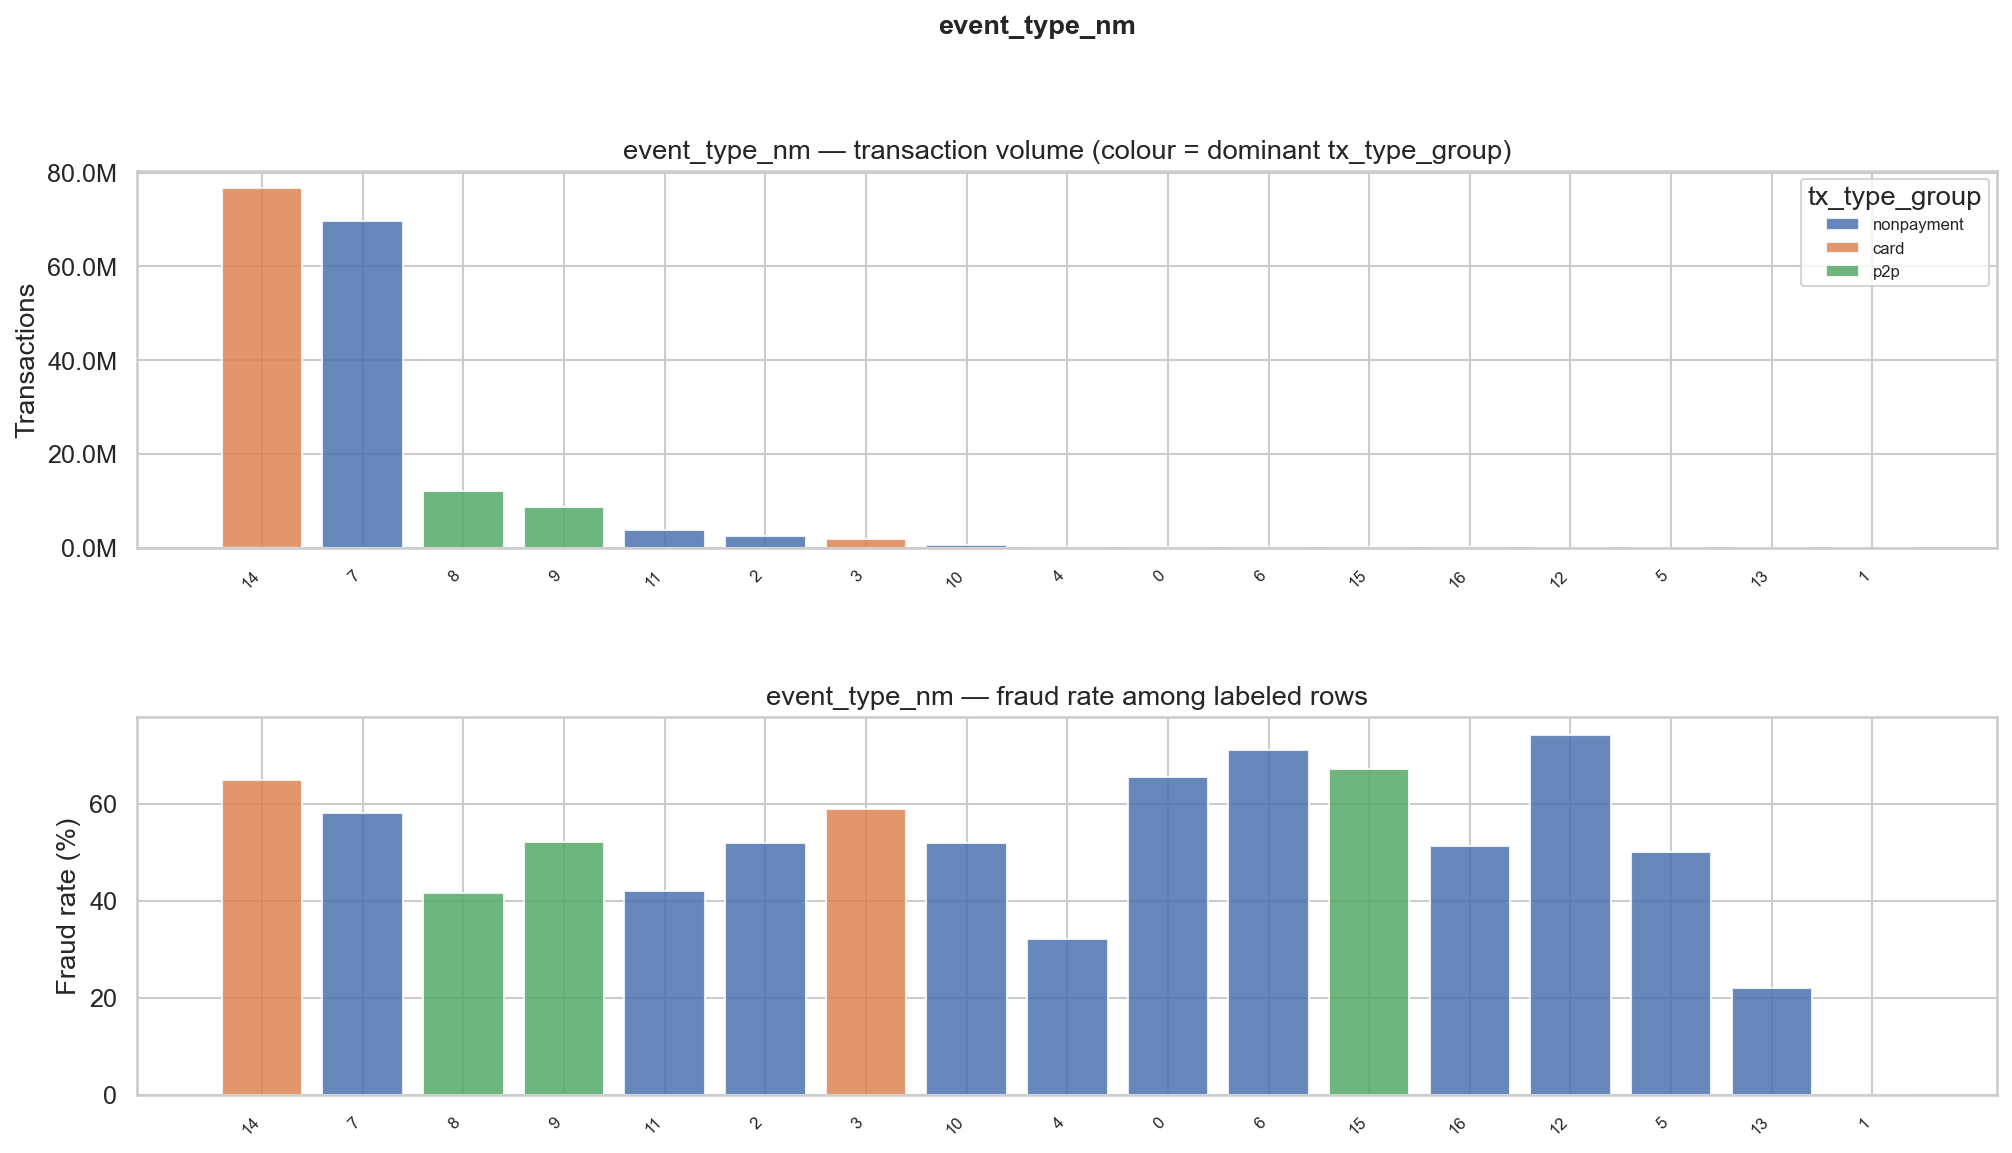

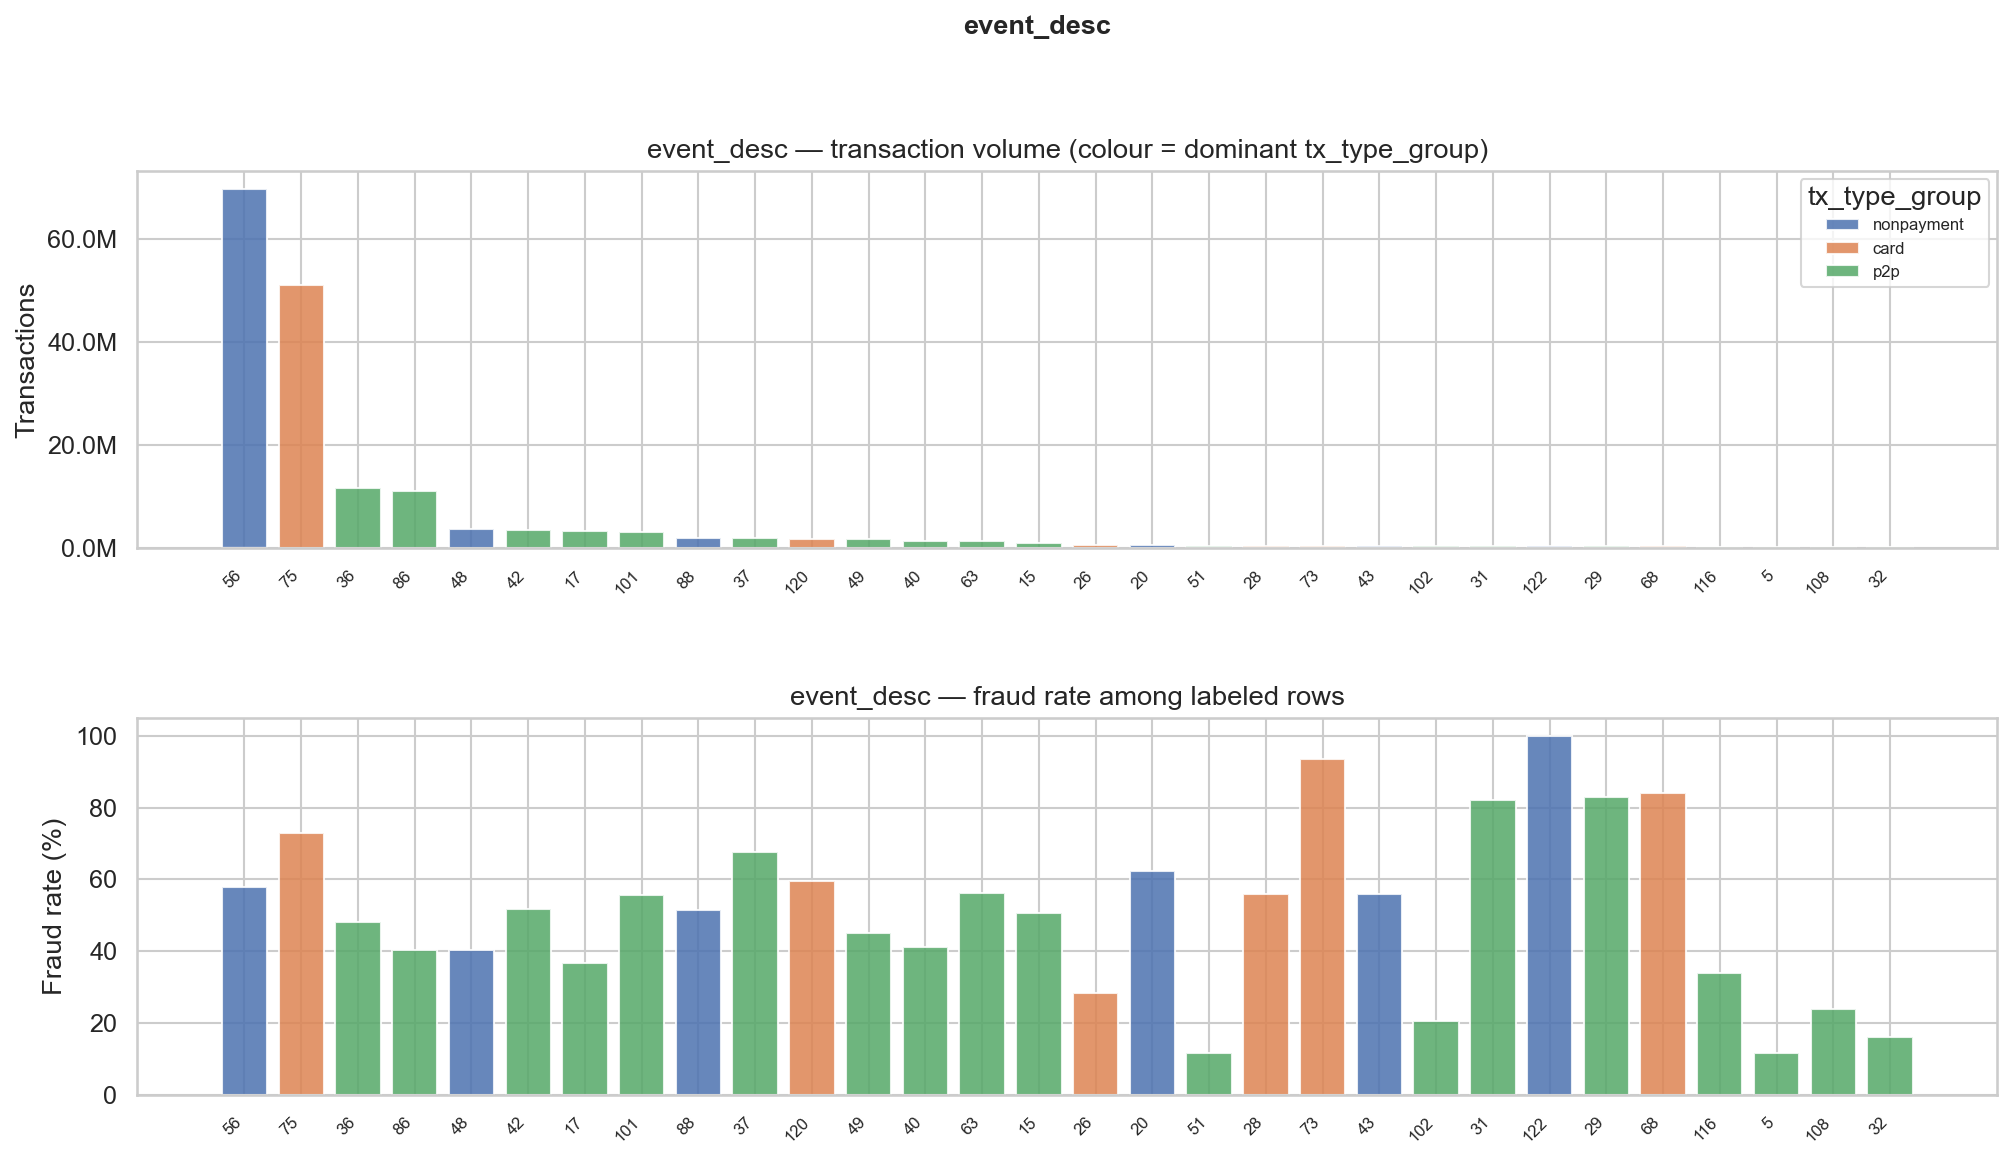

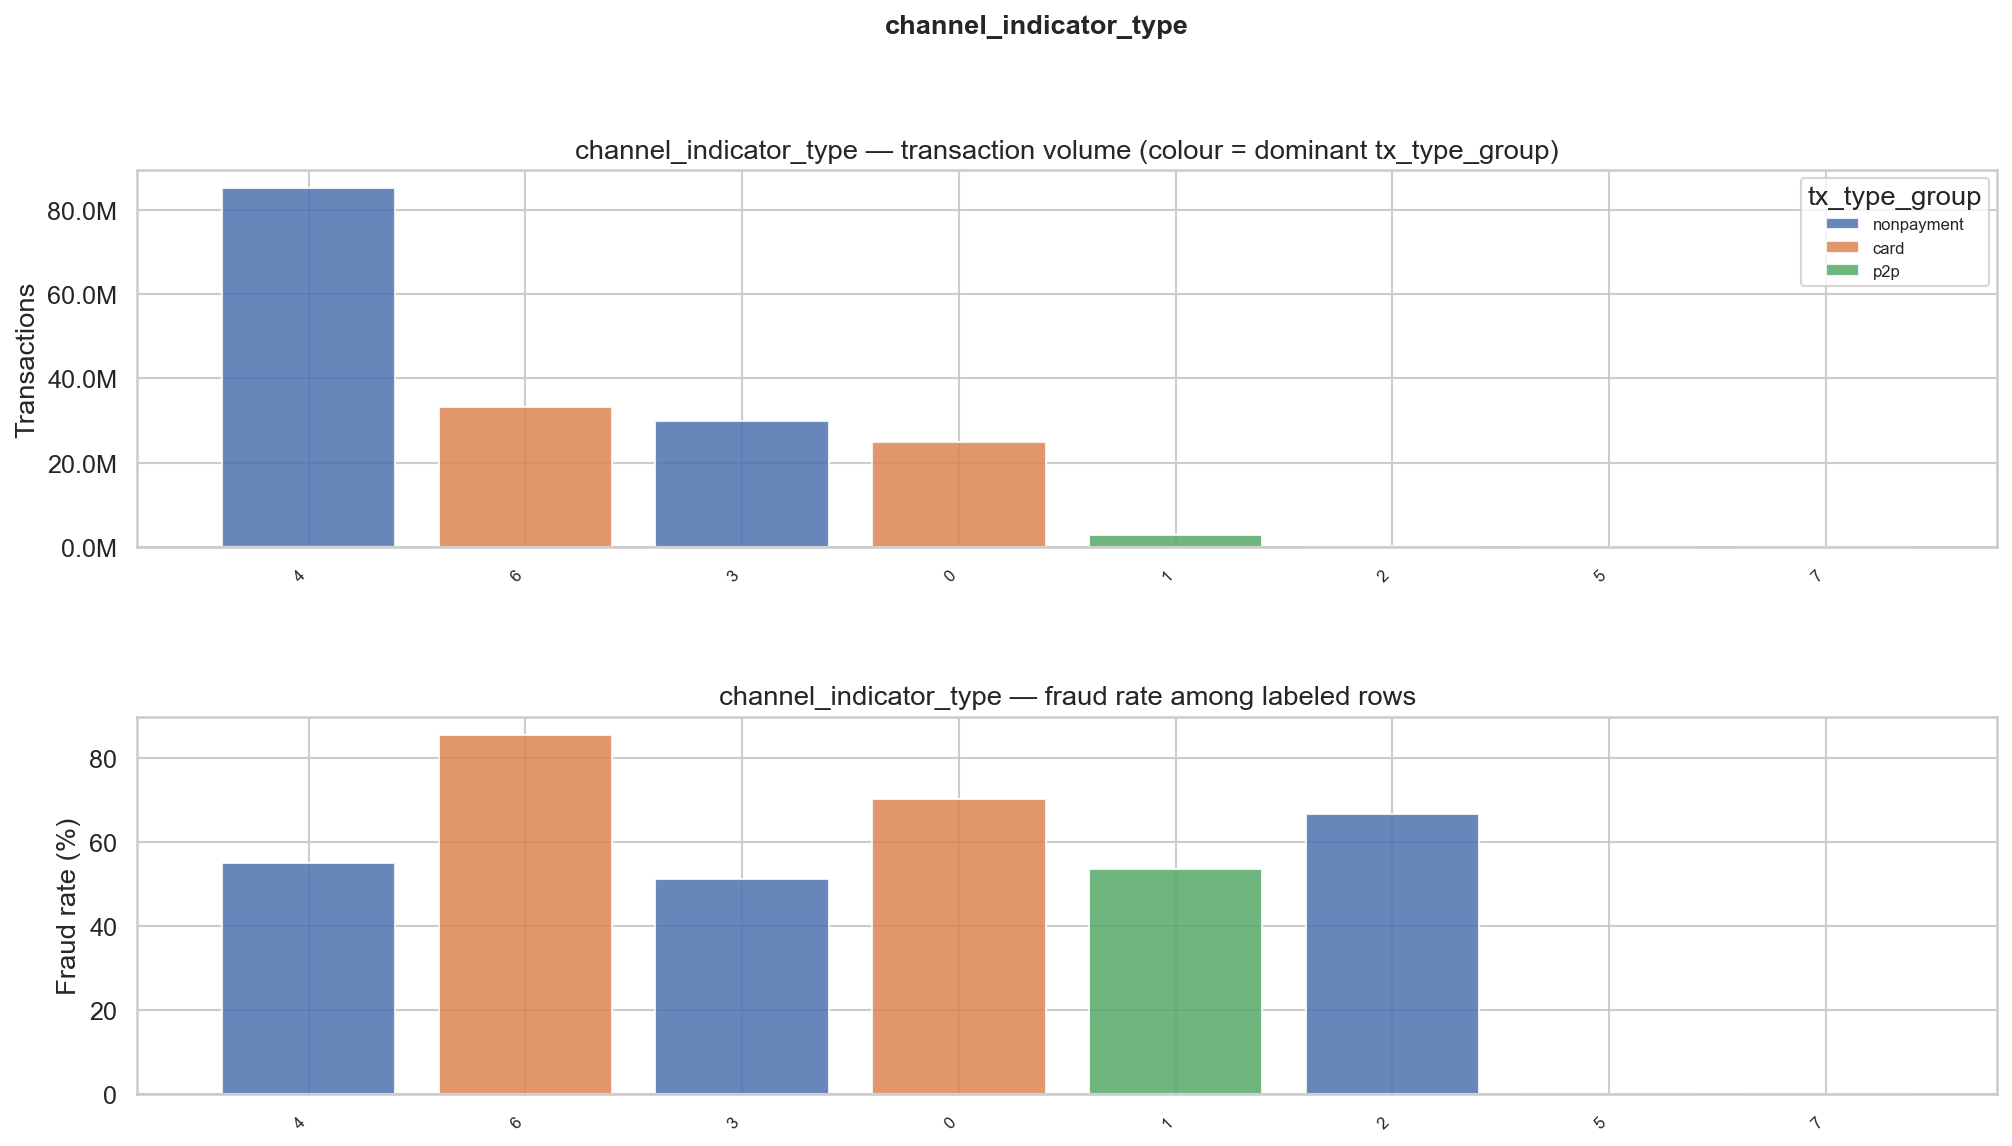

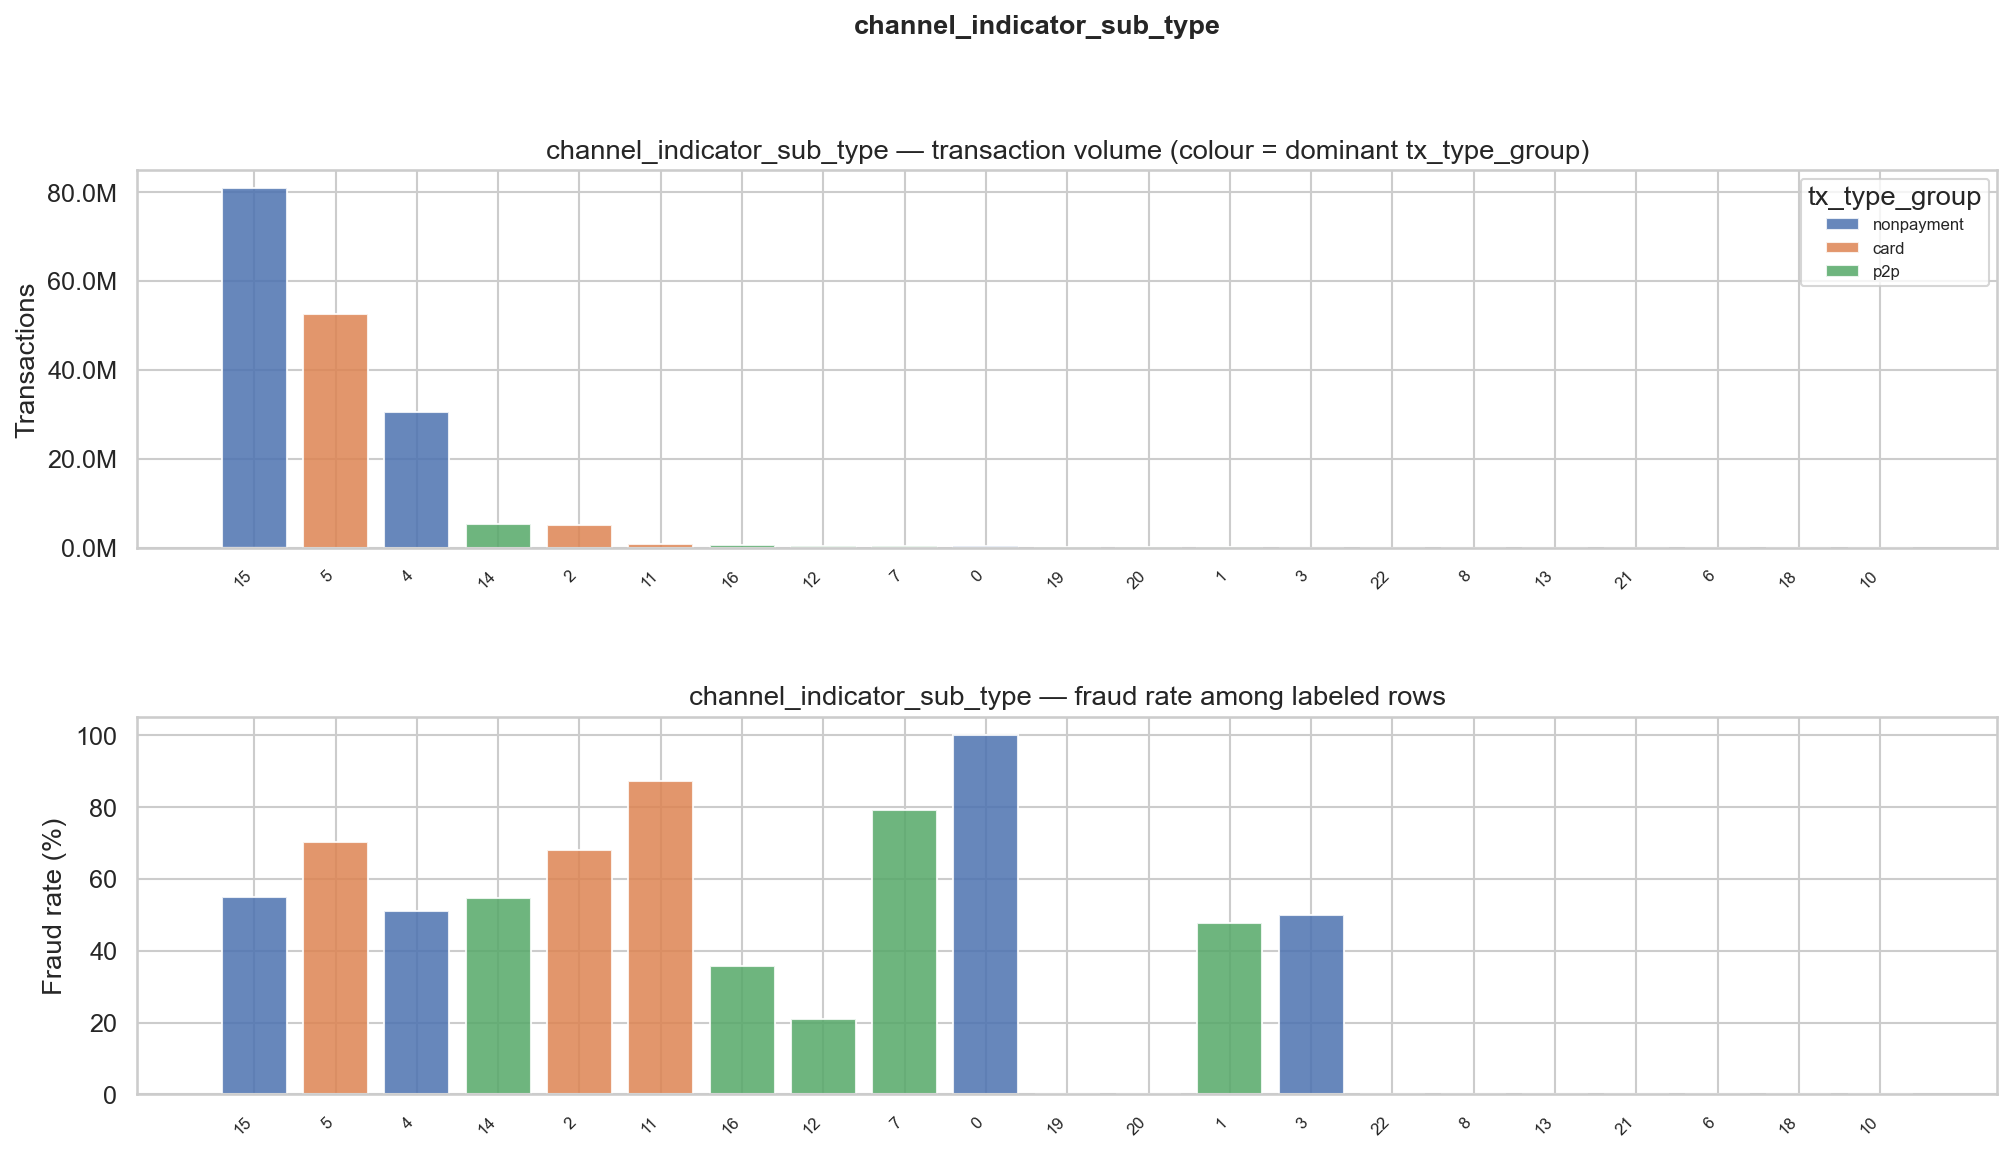

In [4]:

def plot_volume_and_fraud(col_name: str, df: pl.DataFrame, top_n: int = 30):
    sub = df.head(top_n).to_pandas()
    labels = sub[col_name].astype(str)
    x = np.arange(len(labels))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), dpi=150,
                                   gridspec_kw={"hspace": 0.45})

    colors = [GROUP_COLORS.get(g, "#aaa") for g in sub["tx_type_group_mode"]]
    ax1.bar(x, sub["total_count"], color=colors, alpha=0.85, edgecolor="white")
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
    ax1.set_title(f"{col_name} — transaction volume (colour = dominant tx_type_group)")
    ax1.set_ylabel("Transactions")

    # Legend
    for gid, gname in GROUP_LABELS.items():
        ax1.bar(0, 0, color=GROUP_COLORS[gid], label=gname, alpha=0.85)
    ax1.legend(title="tx_type_group", fontsize=8)

    fraud_vals = sub["fraud_rate_pct"].fillna(0)
    ax2.bar(x, fraud_vals, color=colors, alpha=0.85, edgecolor="white")
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax2.set_title(f"{col_name} — fraud rate among labeled rows")
    ax2.set_ylabel("Fraud rate (%)")

    plt.suptitle(col_name, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


for col_name, df in vc.items():
    plot_volume_and_fraud(col_name, df)

Computing cross-tabs vs tx_type_group …


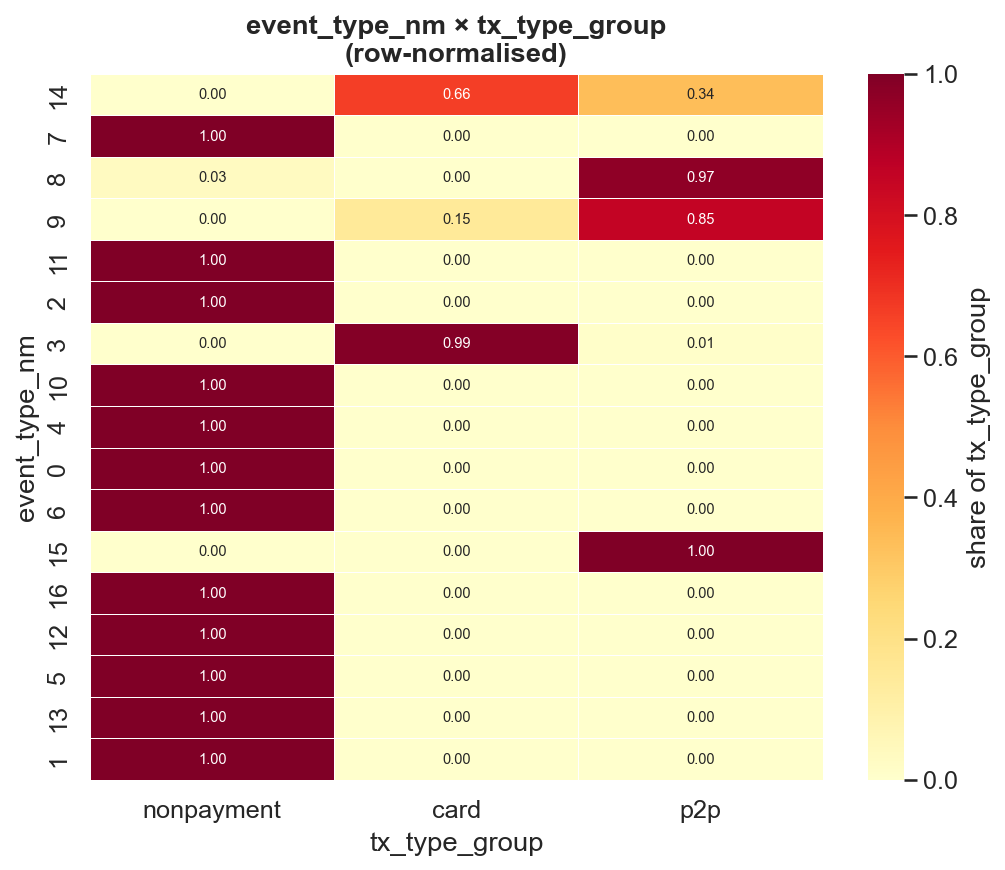

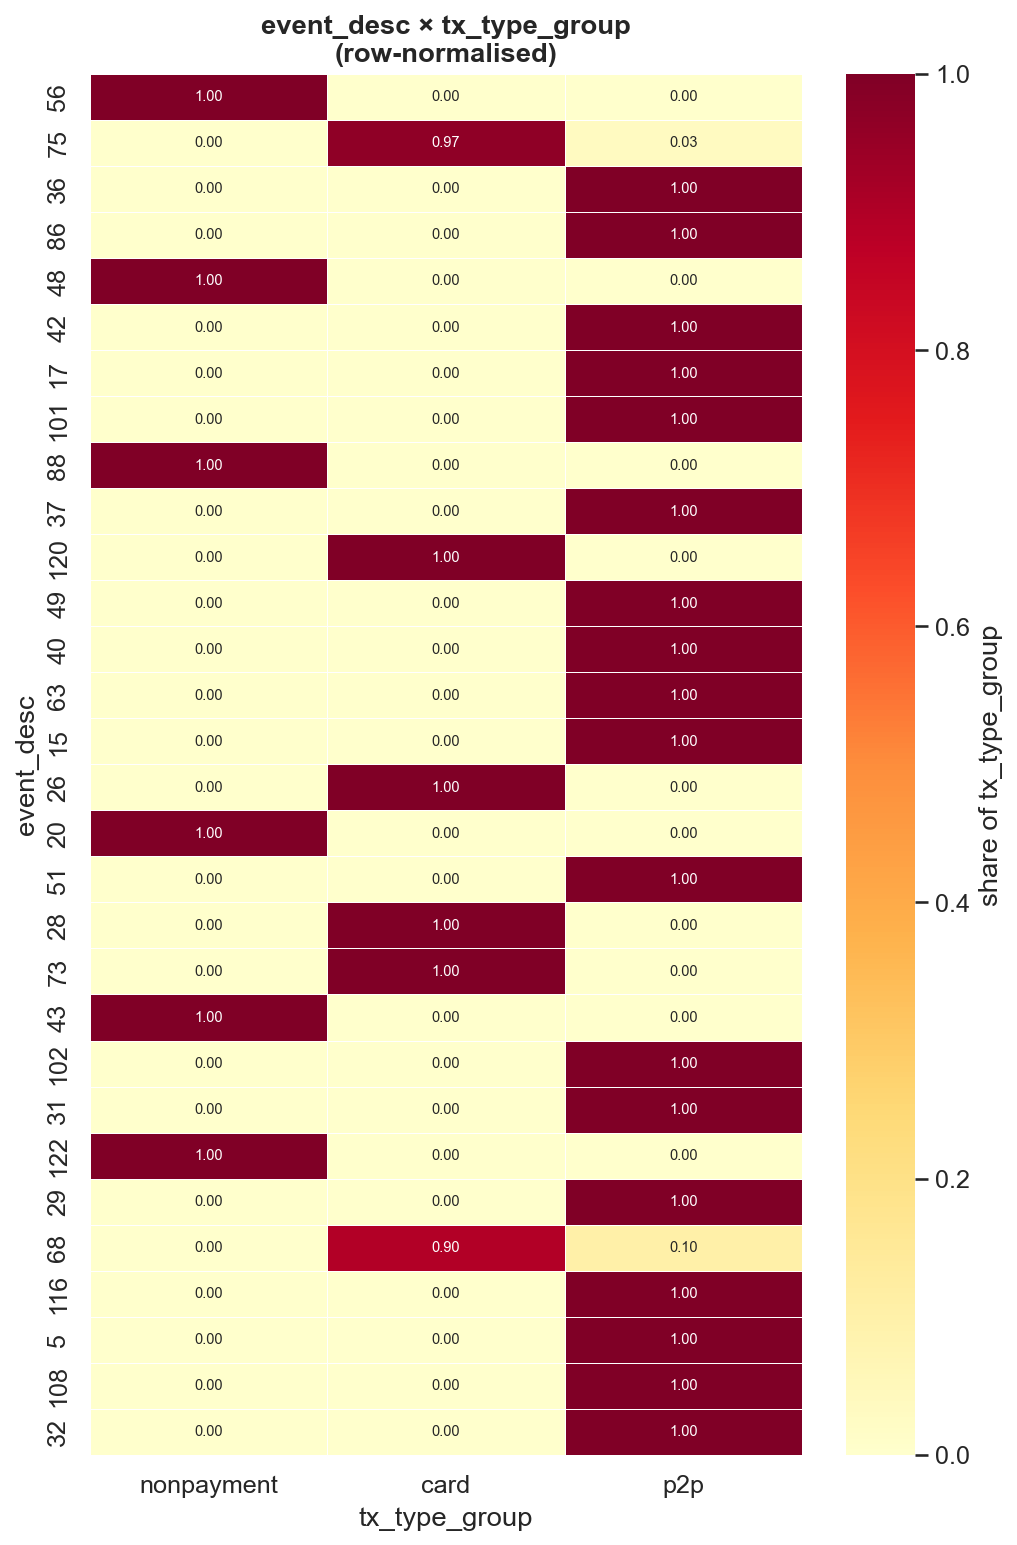

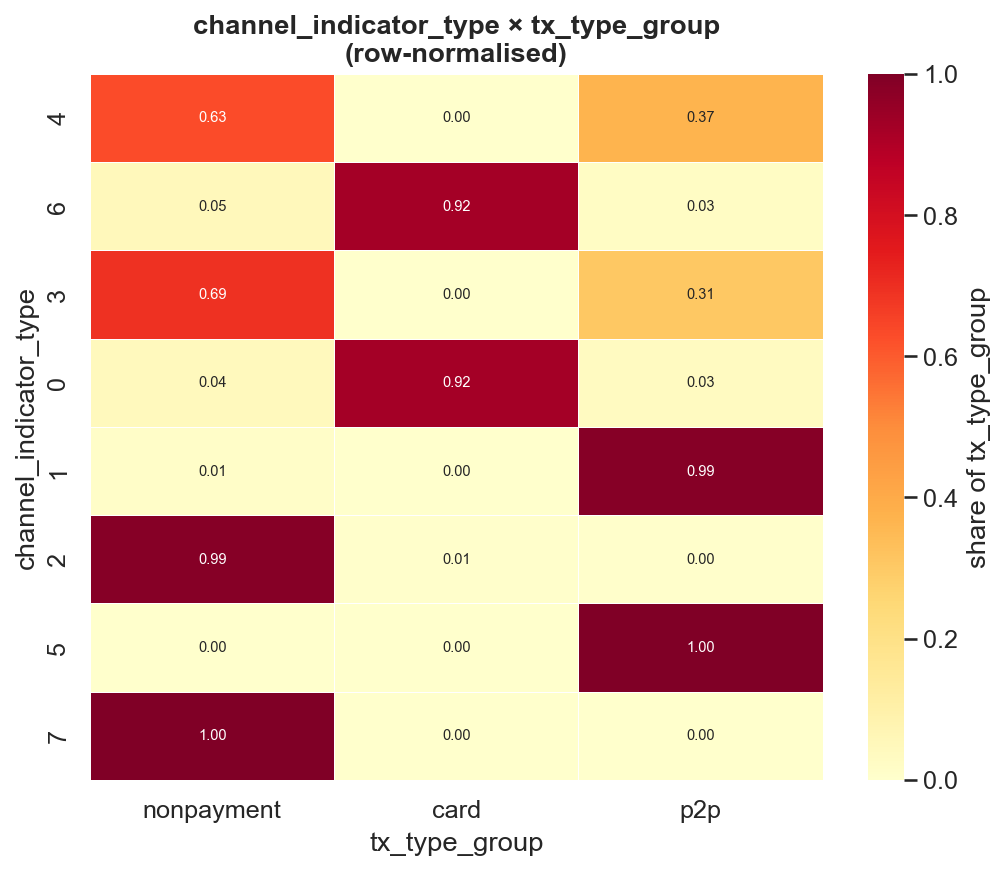

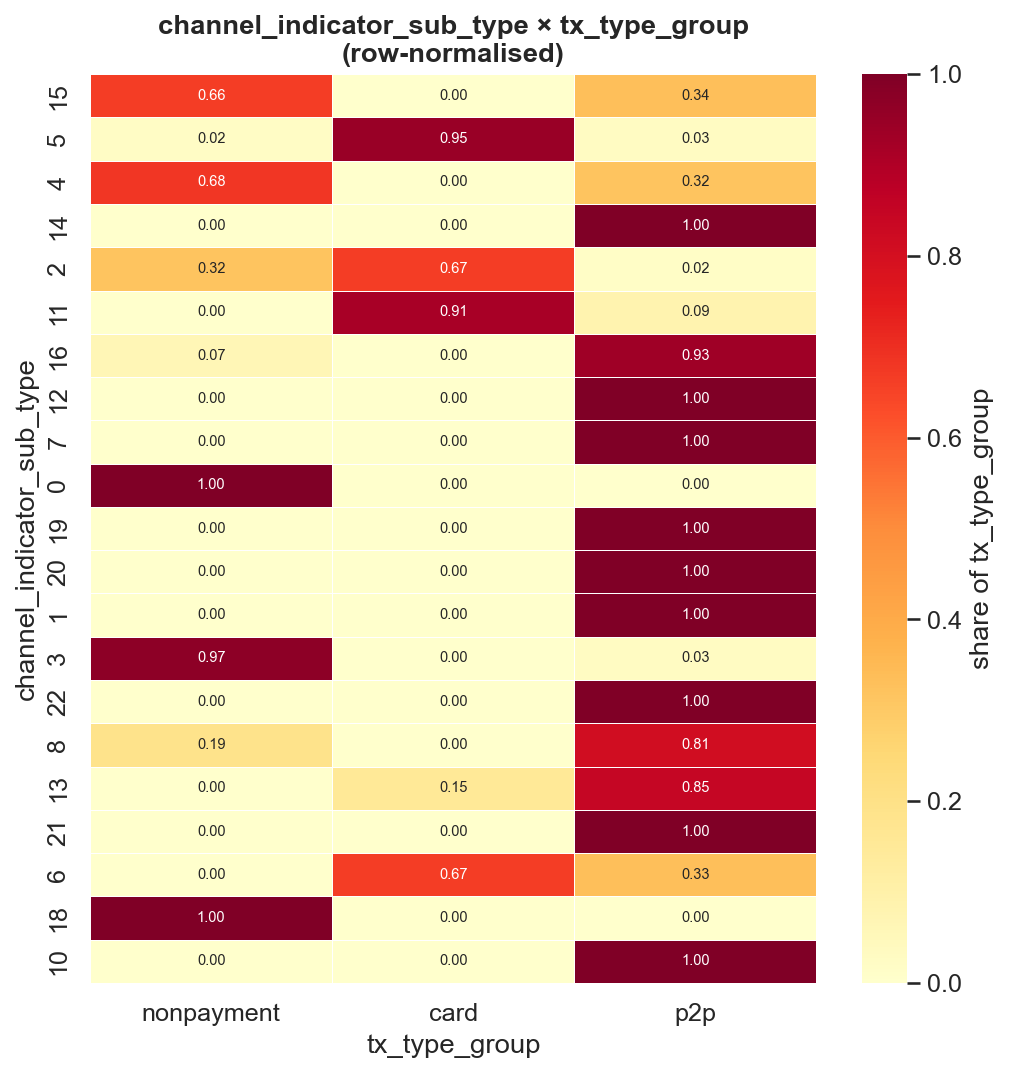

In [5]:

def crosstab_with_group(col_name: str, top_n: int = 30) -> pl.DataFrame:
    """Row-normalised share of each tx_type_group within every category value."""
    df = (
        lf_all
        .group_by([col_name, "tx_type_group"])
        .agg(pl.len().alias("n"))
        .collect()
    )
    # Keep top_n values by total volume
    top_vals = (
        df.group_by(col_name)
          .agg(pl.col("n").sum().alias("total"))
          .sort("total", descending=True)
          .head(top_n)[col_name]
          .to_list()
    )
    df = df.filter(pl.col(col_name).is_in(top_vals))
    # Pivot to wide and row-normalise
    pivot = (
        df.pivot(index=col_name, on="tx_type_group", values="n", aggregate_function="sum")
          .fill_null(0)
    )
    # Ensure all three group columns exist
    for g in [0, 1, 2]:
        if str(g) not in pivot.columns:
            pivot = pivot.with_columns(pl.lit(0).alias(str(g)))
    row_sums = pivot.select(["0", "1", "2"]).to_numpy().sum(axis=1, keepdims=True)
    norm = pivot.select(["0", "1", "2"]).to_numpy() / np.maximum(row_sums, 1)
    result = pivot.select([col_name]).to_pandas()
    result["nonpayment"] = norm[:, 0]
    result["card"]        = norm[:, 1]
    result["p2p"]         = norm[:, 2]
    # Sort by total volume order
    order = {v: i for i, v in enumerate(top_vals)}
    result = result.sort_values(col_name, key=lambda s: s.map(order)).reset_index(drop=True)
    return result


print("Computing cross-tabs vs tx_type_group …")
for col_name in CATS:
    ct = crosstab_with_group(col_name, top_n=30)
    # Save
    ct.to_csv(OUT_DIR / f"crosstab_tx_group__{col_name}.csv", index=False)
    heat_data = ct[["nonpayment", "card", "p2p"]].values
    row_labels = ct[col_name].astype(str).tolist()

    fig, ax = plt.subplots(figsize=(7, max(6, len(row_labels) * 0.35)), dpi=150)
    sns.heatmap(
        heat_data, ax=ax,
        xticklabels=["nonpayment", "card", "p2p"],
        yticklabels=row_labels,
        cmap="YlOrRd", vmin=0, vmax=1,
        linewidths=0.4, linecolor="white",
        annot=len(row_labels) <= 30,
        fmt=".2f", annot_kws={"fontsize": 7},
        cbar_kws={"label": "share of tx_type_group"},
    )
    ax.set_title(f"{col_name} × tx_type_group\n(row-normalised)", fontweight="bold")
    ax.set_xlabel("tx_type_group")
    ax.set_ylabel(col_name)
    plt.tight_layout()
    plt.show()

Computing within-group stats …


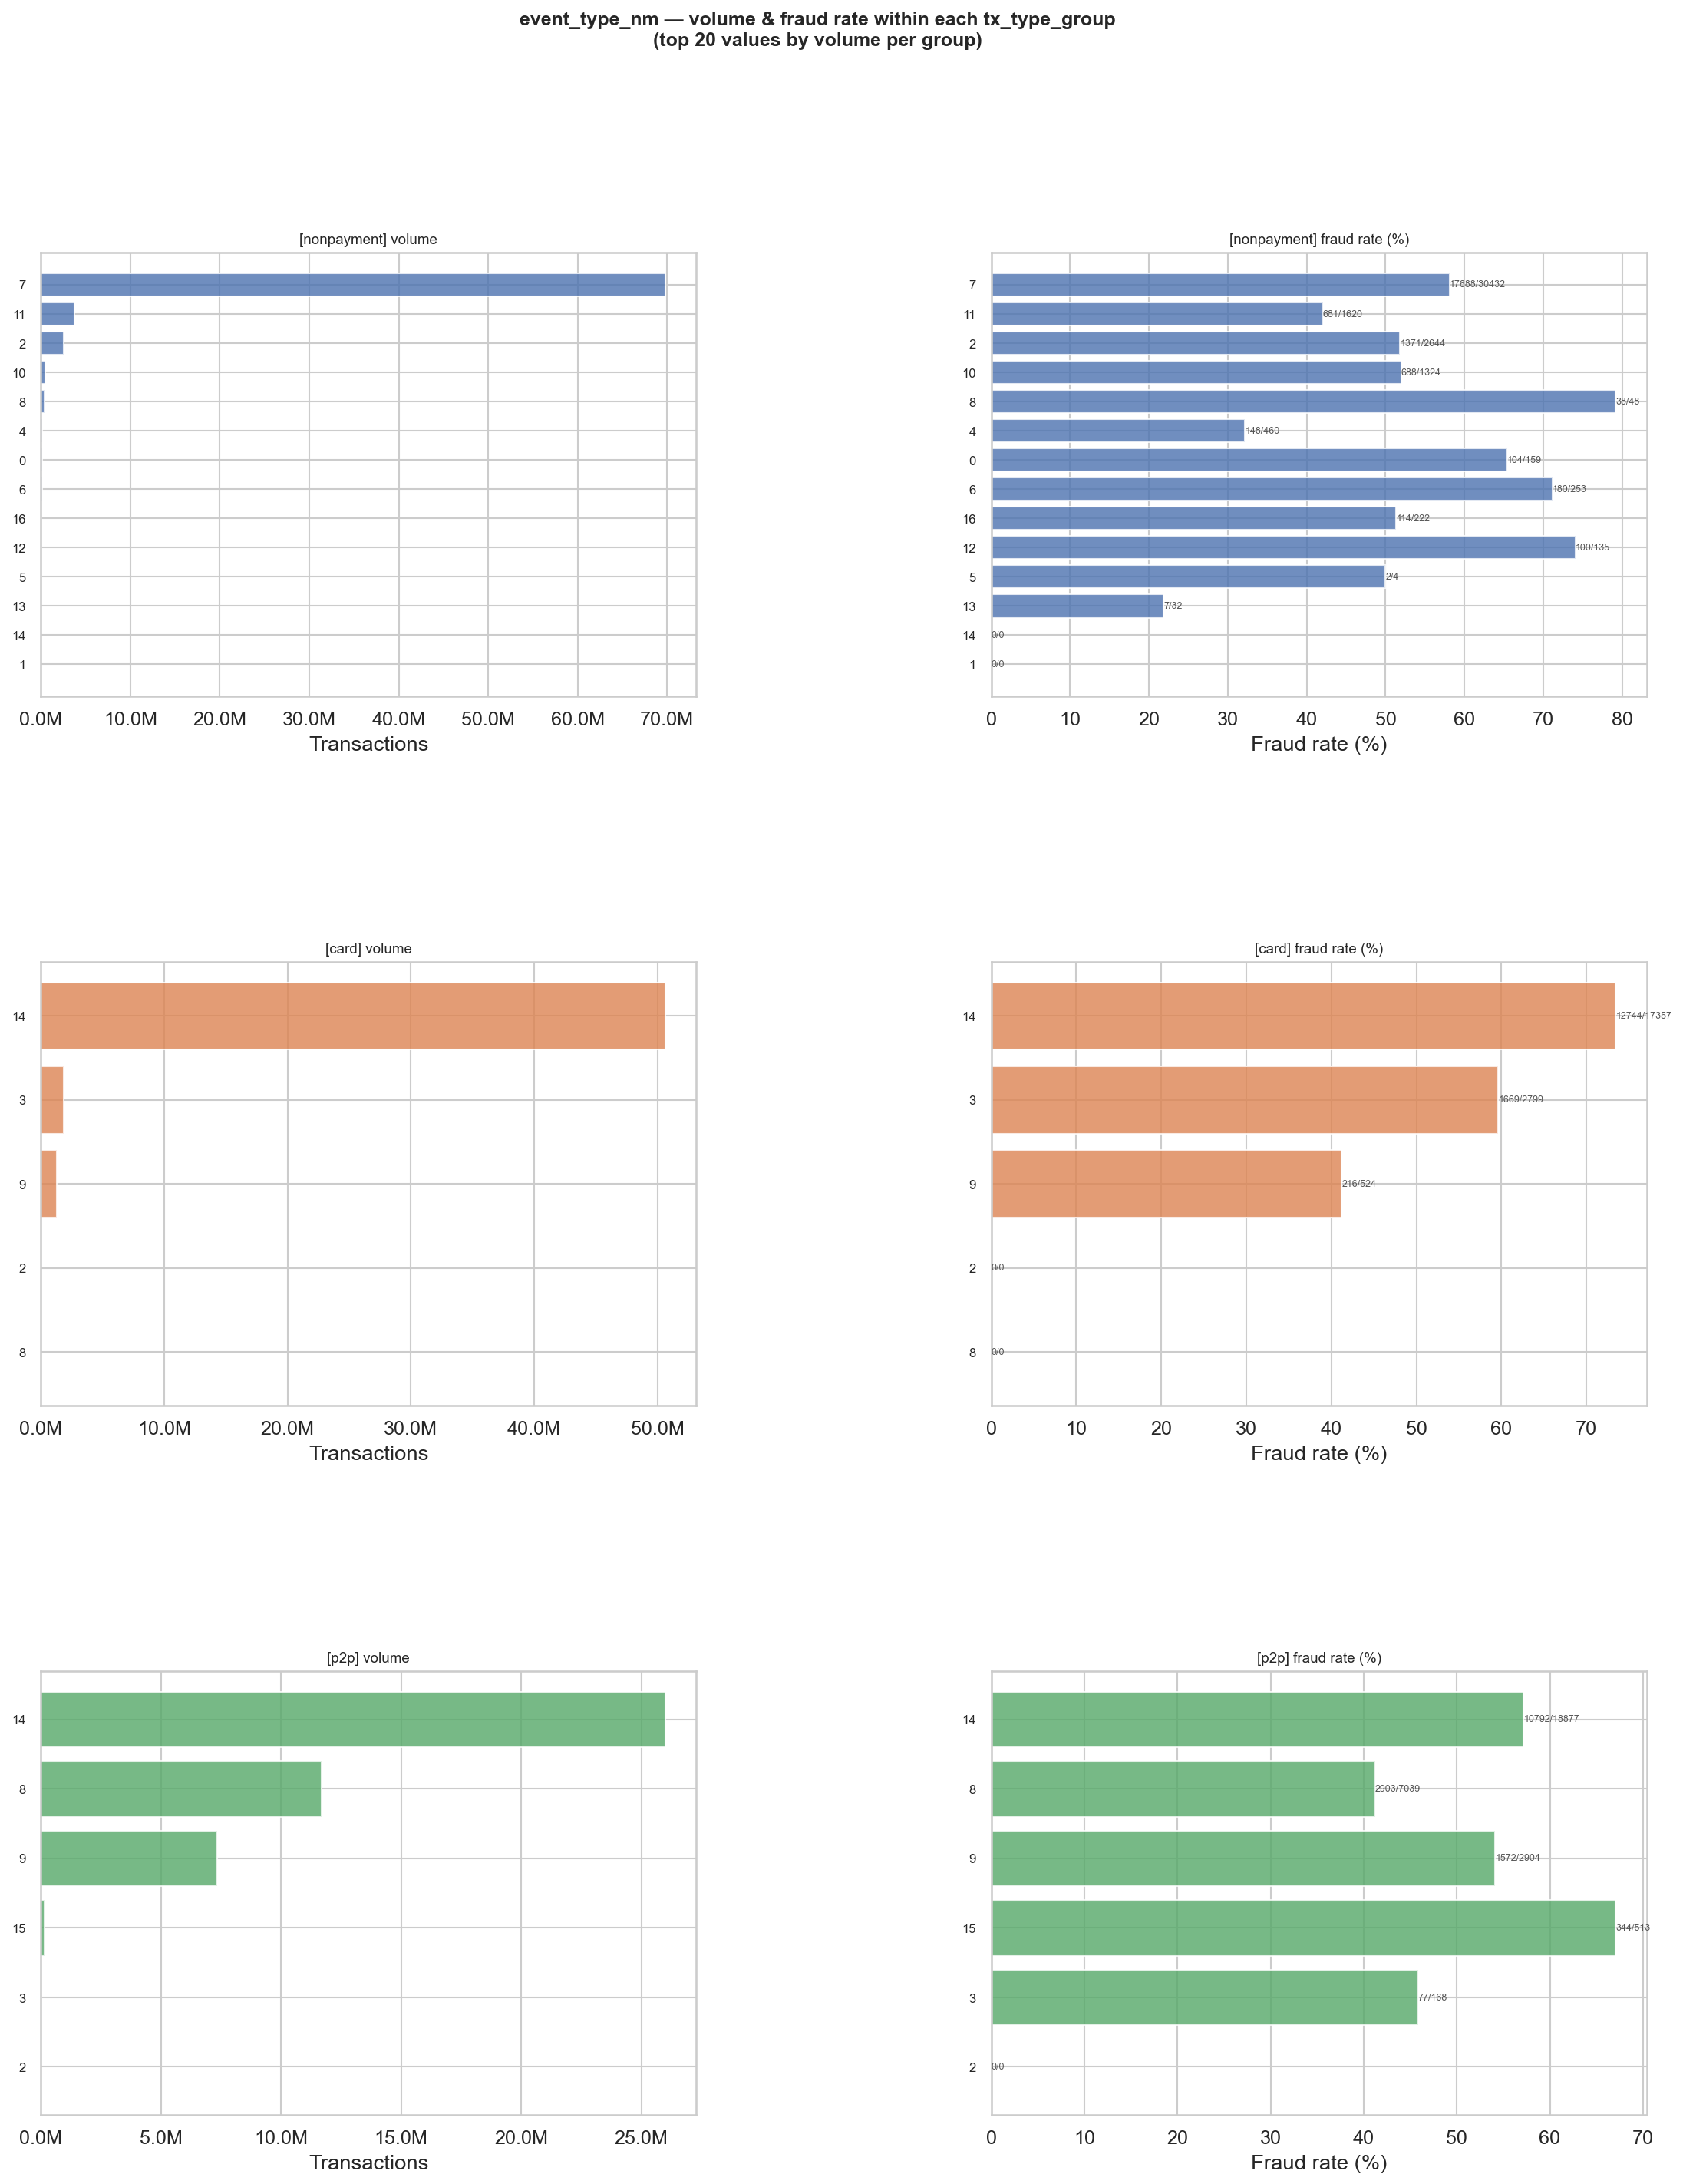

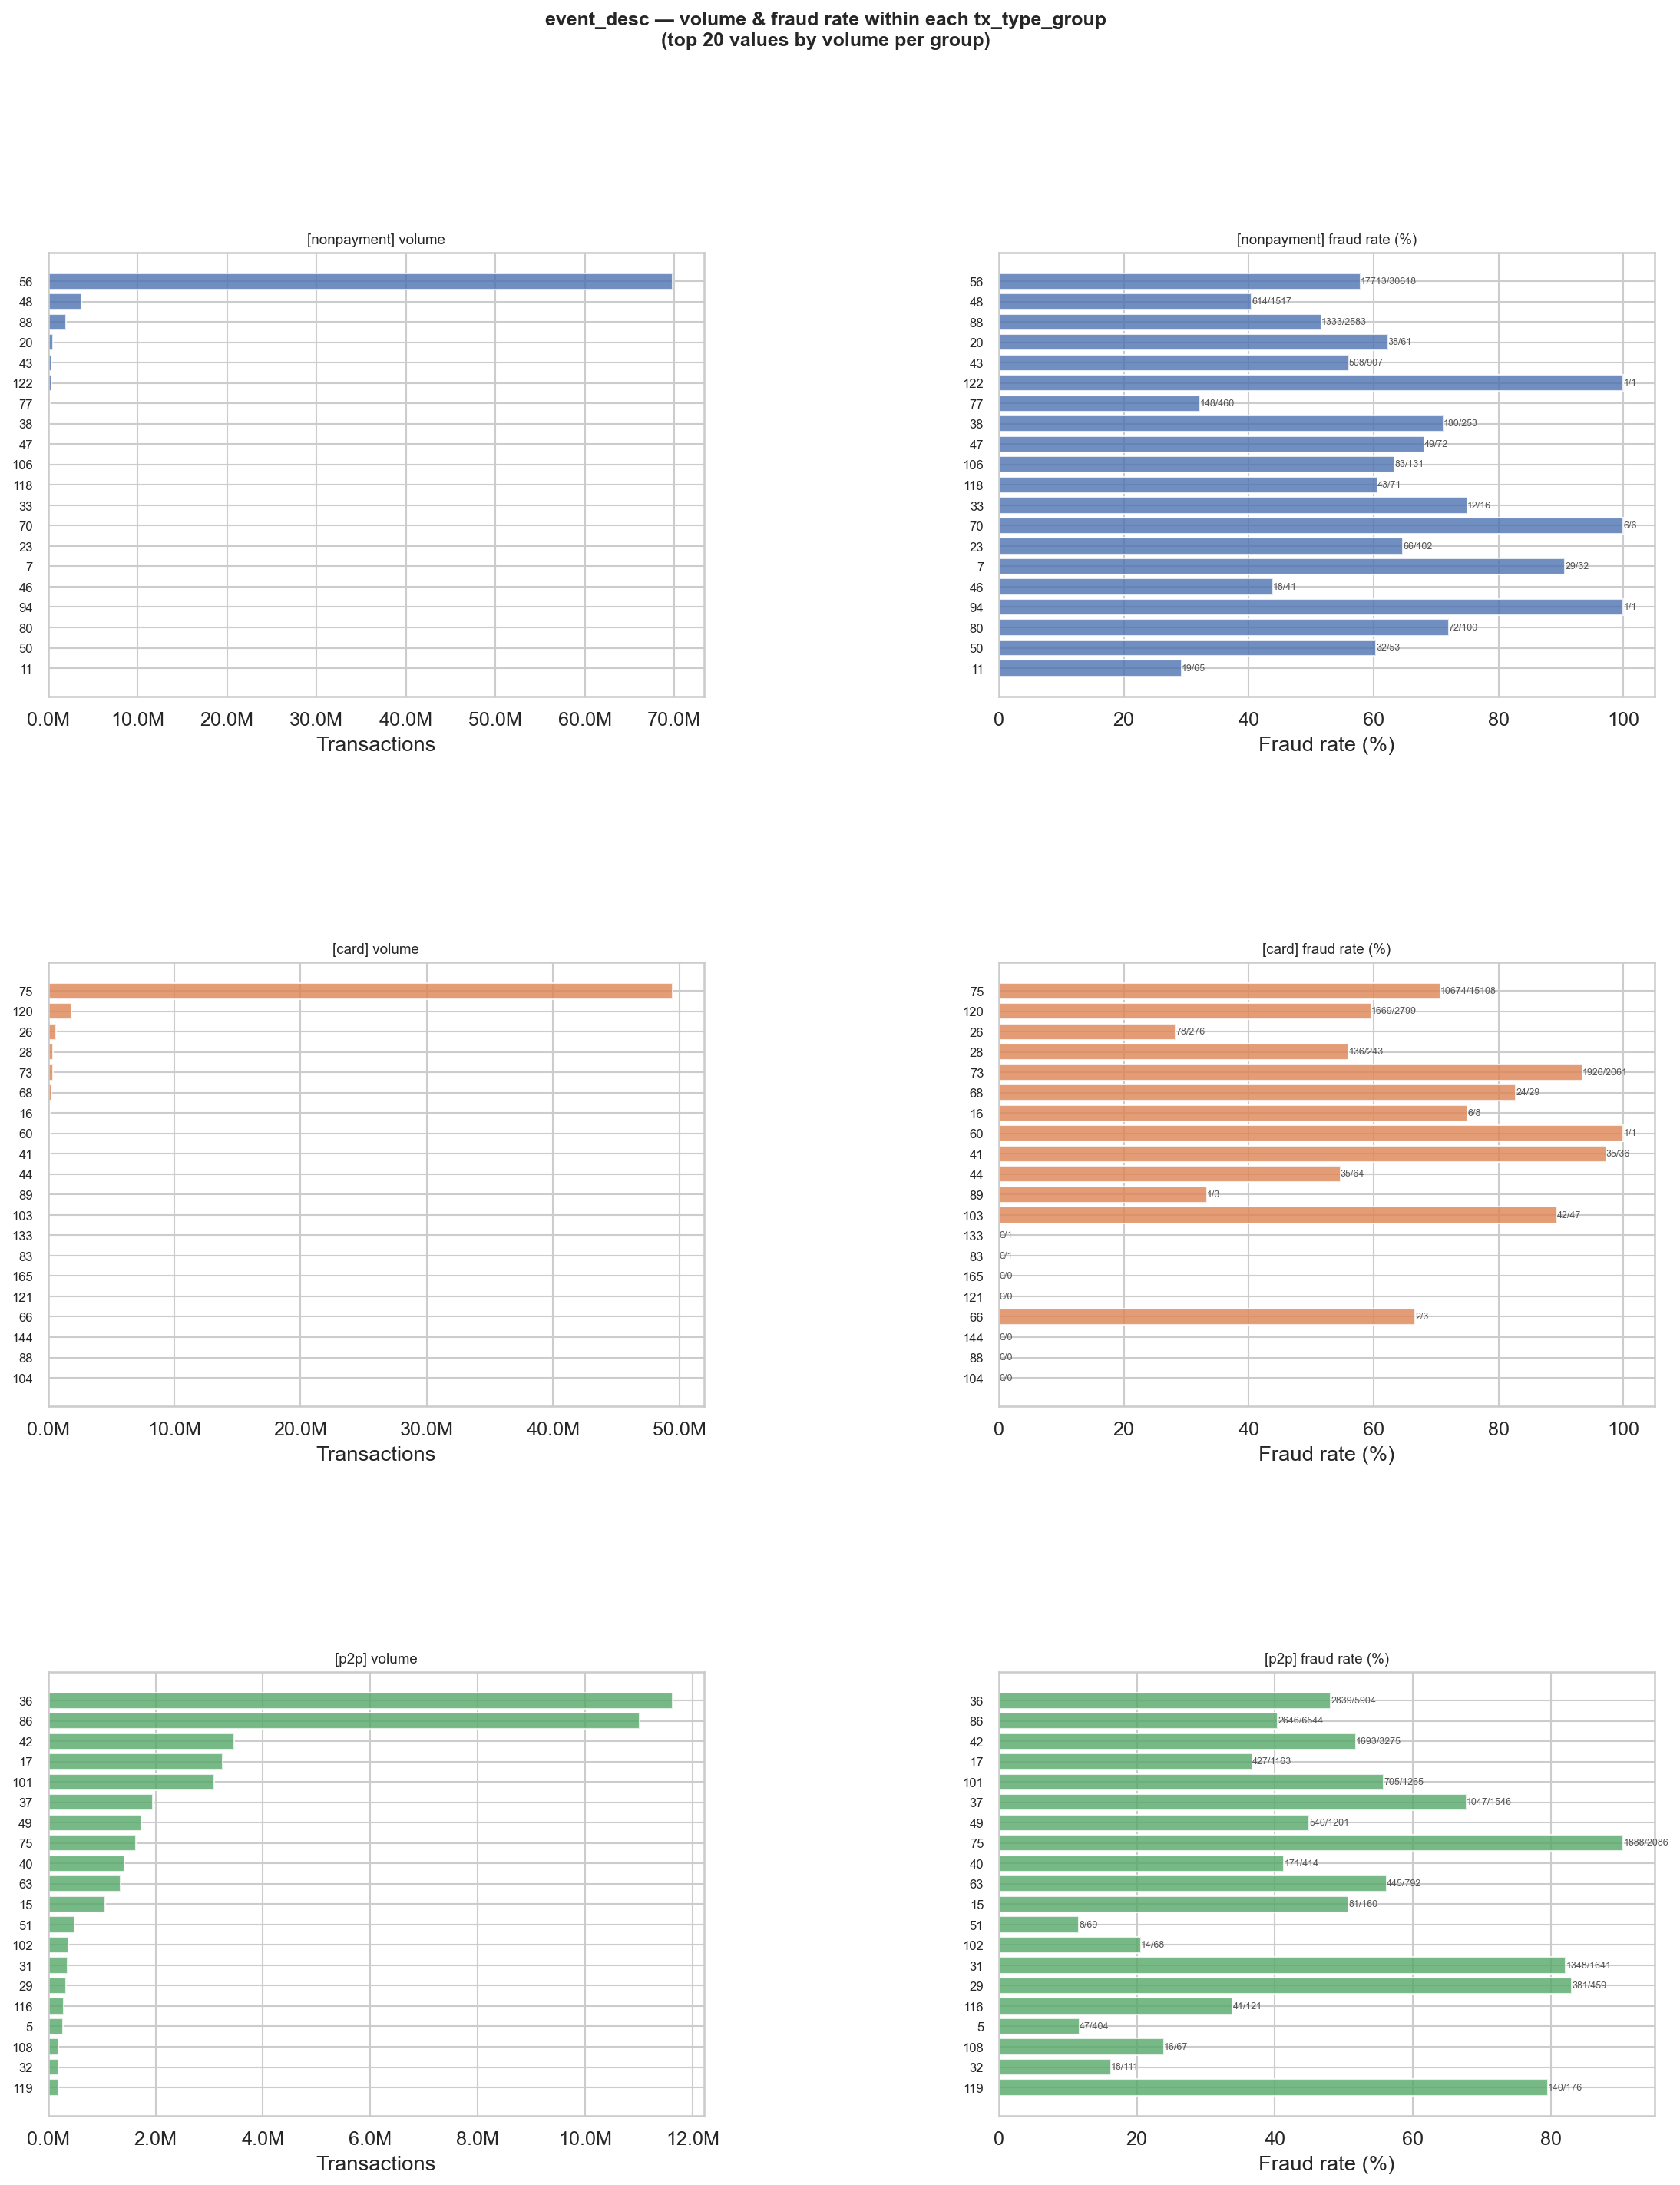

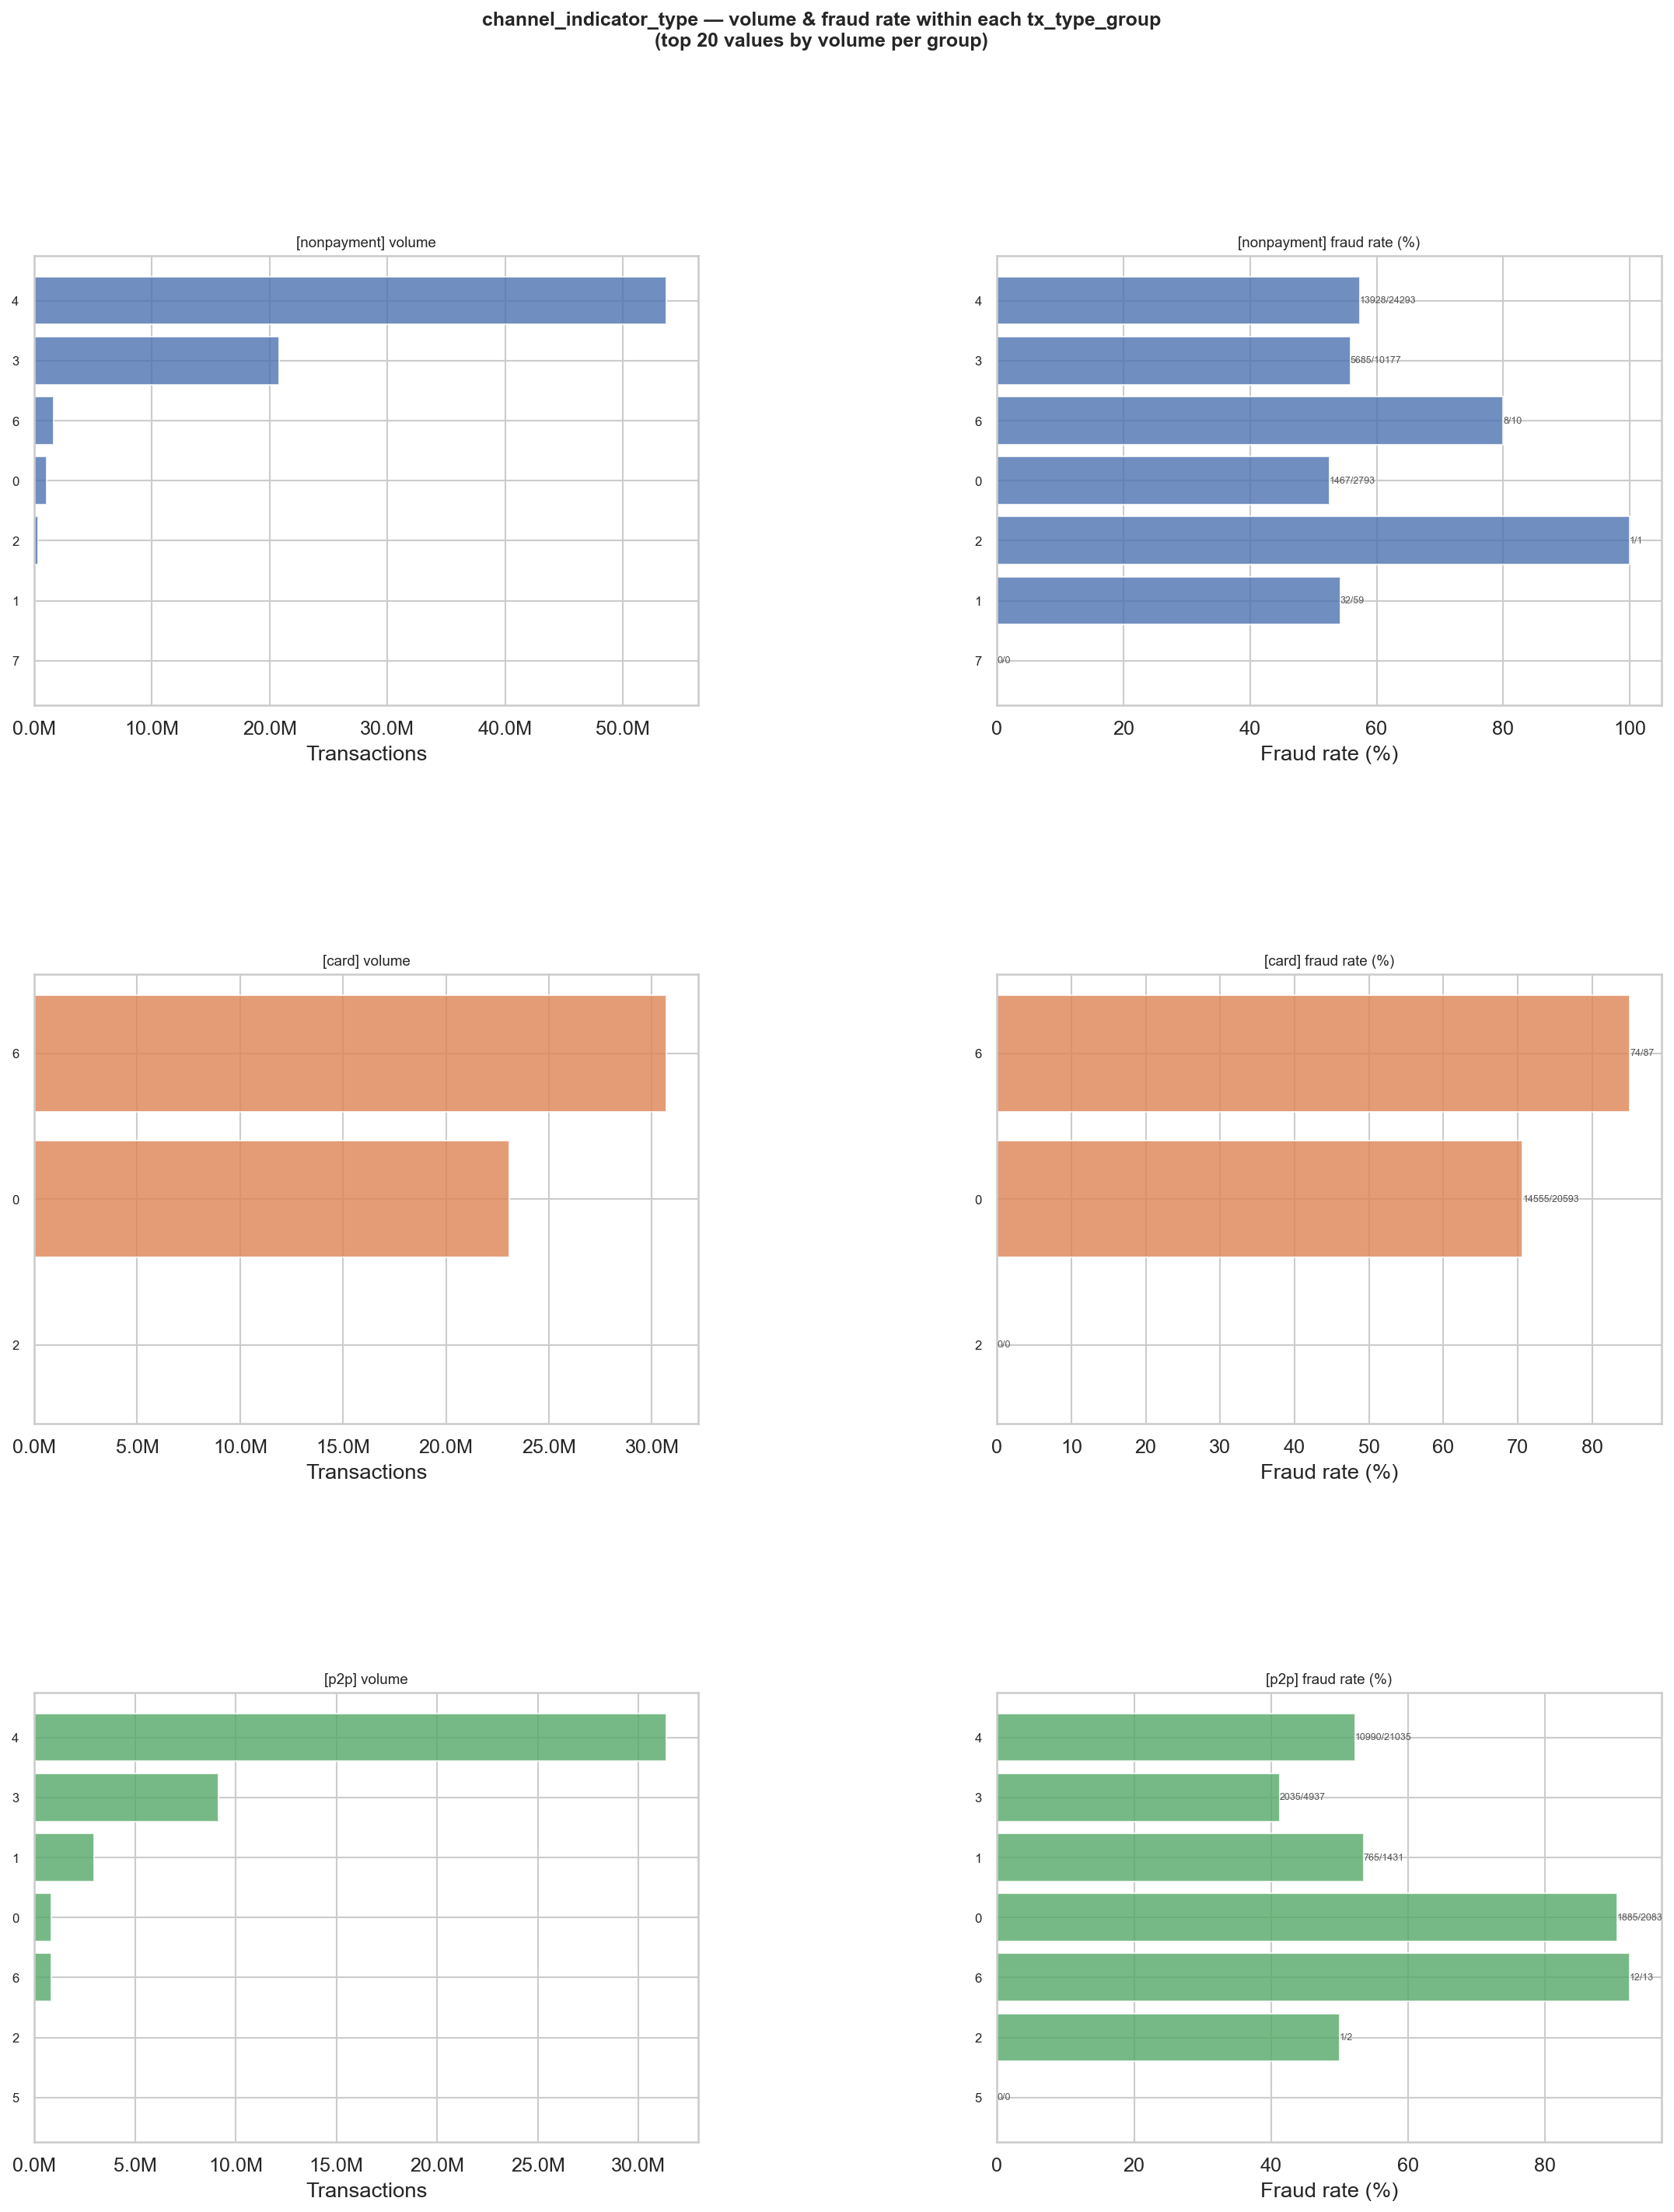

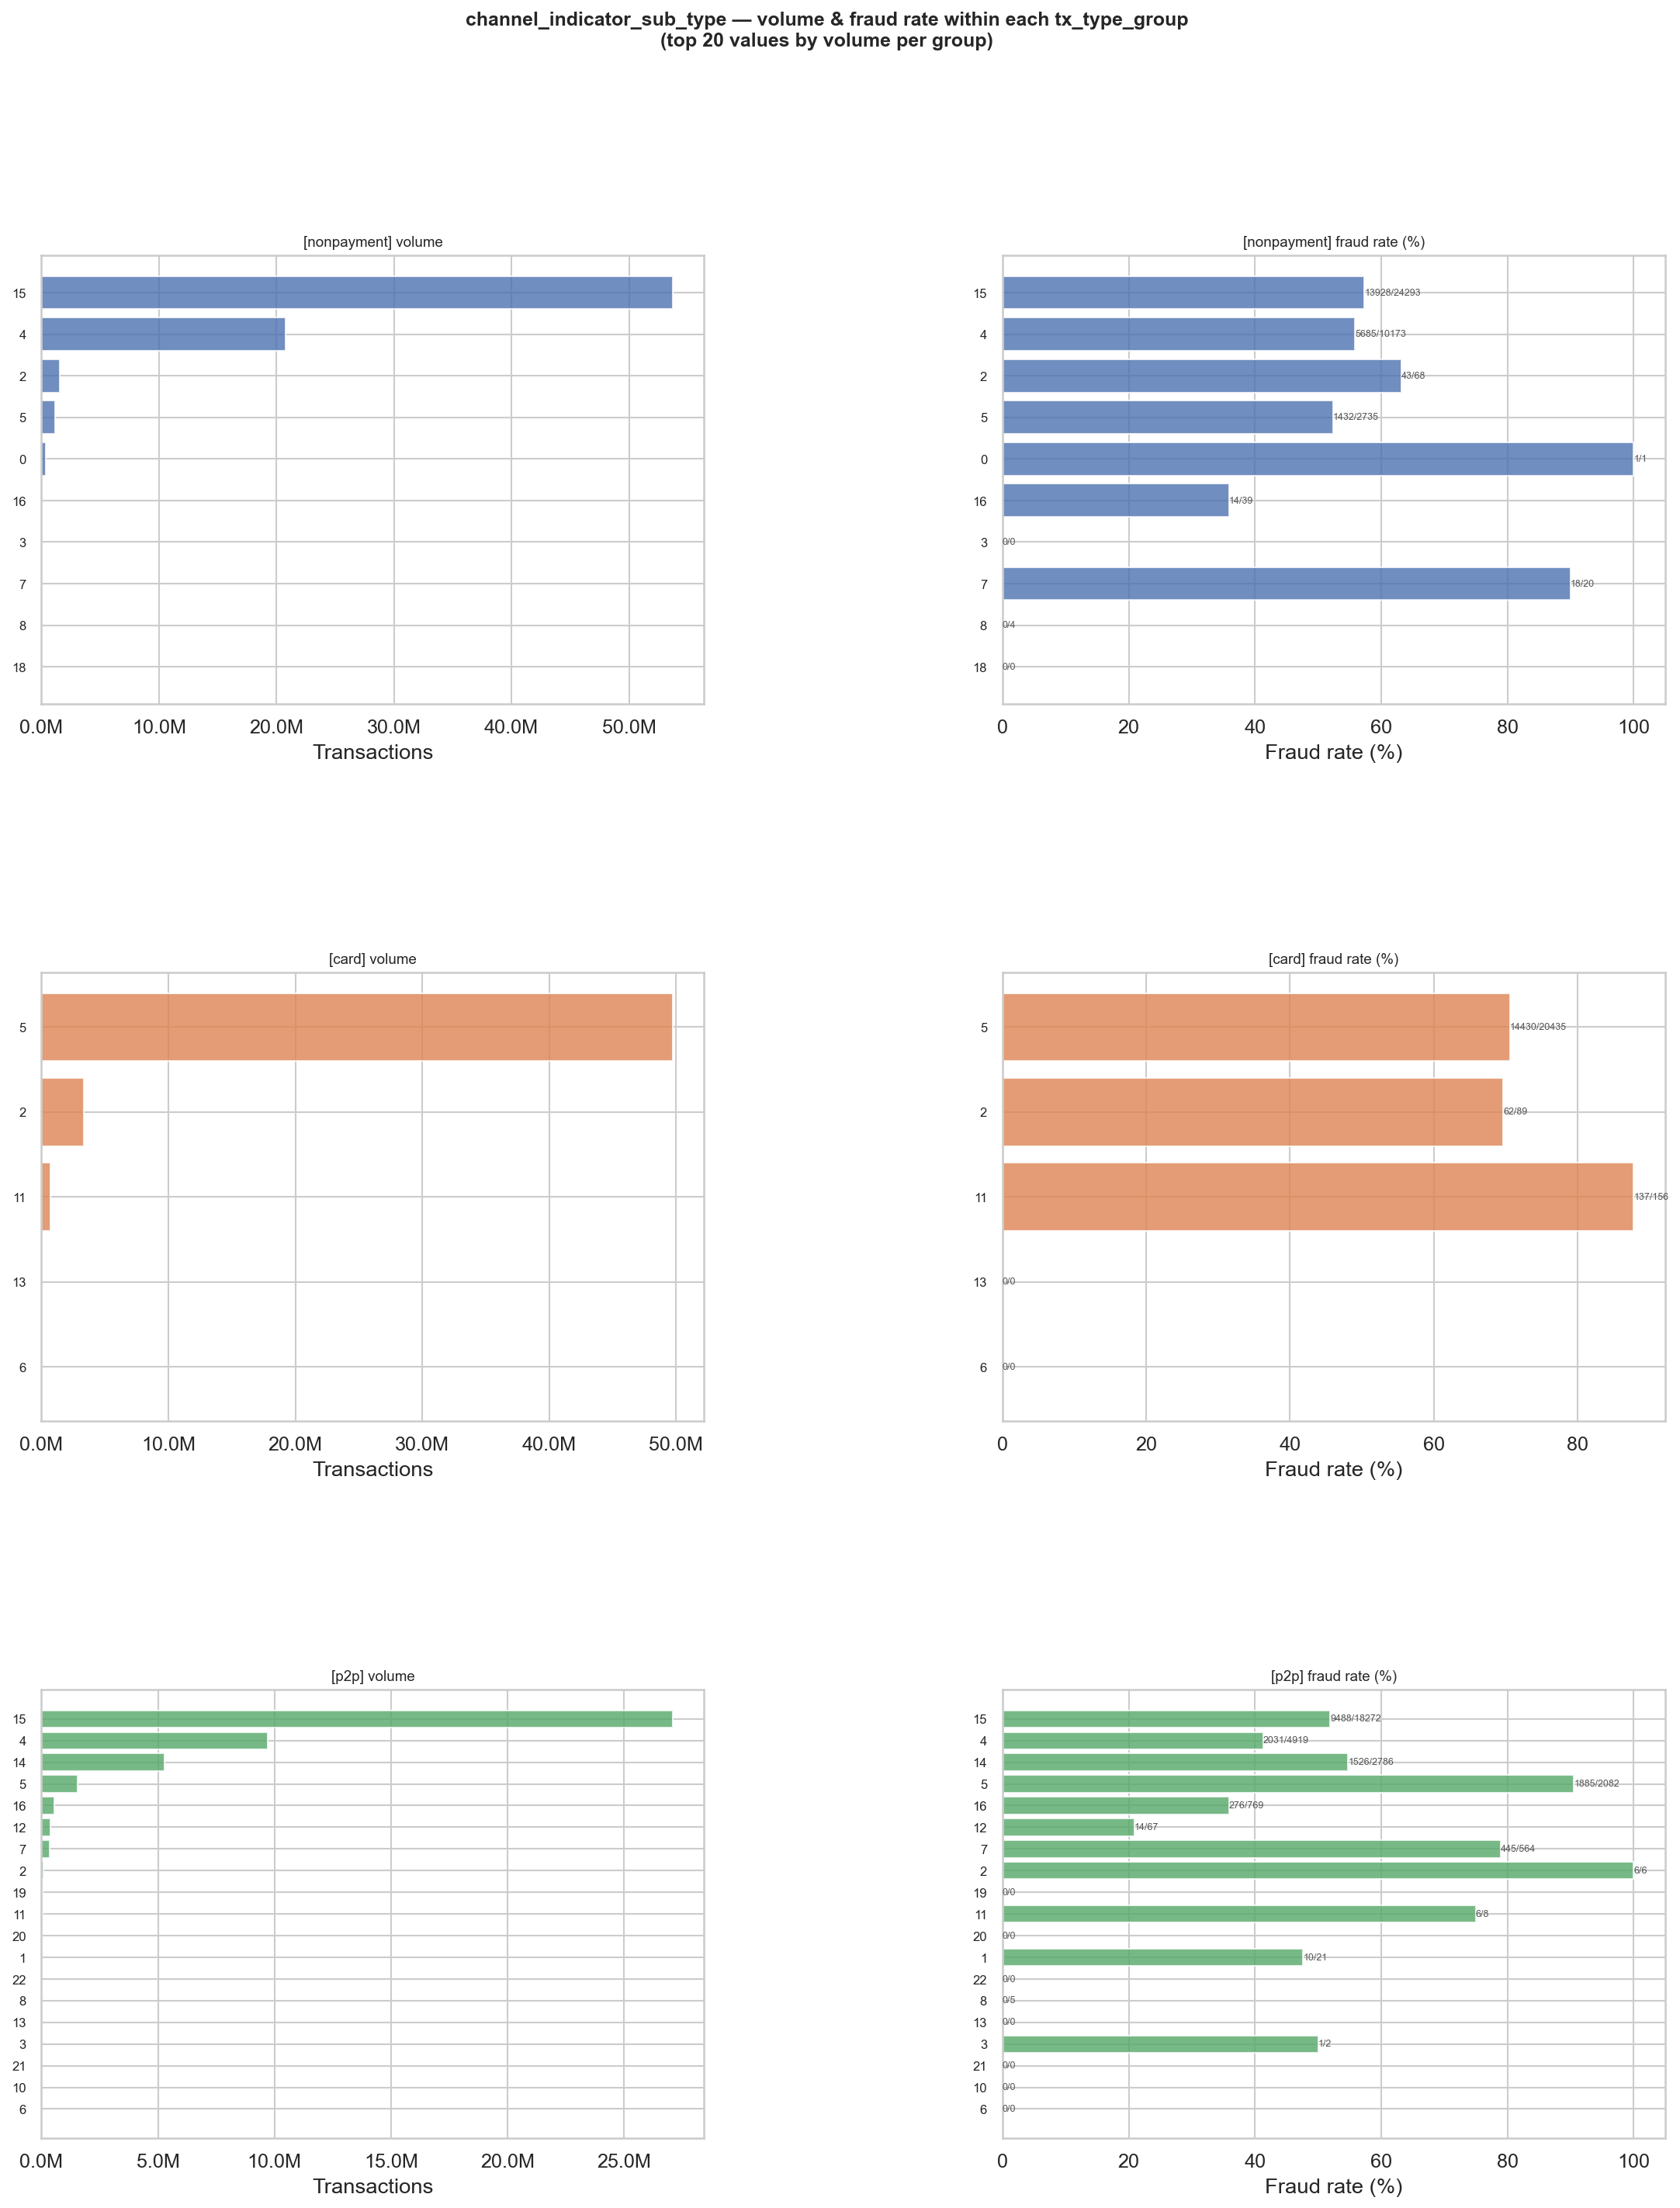

In [6]:
# For each tx_type_group × categorical column: show fraud rate + volume.
# This reveals natural sub-groups inside the current three broad groups.

print("Computing within-group stats …")

def within_group_stats(col_name: str) -> pl.DataFrame:
    """
    For every (tx_type_group, col_name) pair:
        volume (pretrain+train), fraud_count, labeled_count, fraud_rate_pct
    """
    volume = (
        lf_all
        .group_by(["tx_type_group", col_name])
        .agg(pl.len().alias("volume"))
        .collect()
    )
    fraud = (
        lf_labeled
        .group_by(["tx_type_group", col_name])
        .agg(
            pl.col("target").sum().alias("fraud_count"),
            pl.len().alias("labeled_count"),
        )
        .collect()
    )
    df = (
        volume
        .join(fraud, on=["tx_type_group", col_name], how="left")
        .with_columns(
            (pl.col("fraud_count") / pl.col("labeled_count") * 100)
            .alias("fraud_rate_pct")
        )
        .sort(["tx_type_group", "volume"], descending=[False, True])
    )
    return df


def plot_within_group(col_name: str, df: pl.DataFrame, top_n_per_group: int = 20):
    groups = [0, 1, 2]
    fig, axes = plt.subplots(
        len(groups), 2,
        figsize=(18, len(groups) * max(4, top_n_per_group * 0.35)),
        gridspec_kw={"wspace": 0.45, "hspace": 0.6}, dpi=150
    )

    for row, gid in enumerate(groups):
        sub = (
            df.filter(pl.col("tx_type_group") == gid)
              .head(top_n_per_group)
              .to_pandas()
        )
        if sub.empty:
            axes[row, 0].set_visible(False)
            axes[row, 1].set_visible(False)
            continue

        labels = sub[col_name].astype(str).tolist()
        x = np.arange(len(labels))
        color = GROUP_COLORS[gid]

        # Volume
        ax_v = axes[row, 0]
        ax_v.barh(x, sub["volume"], color=color, alpha=0.8, edgecolor="white")
        ax_v.set_yticks(x); ax_v.set_yticklabels(labels, fontsize=8)
        ax_v.invert_yaxis()
        ax_v.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
        ax_v.set_title(f"[{GROUP_LABELS[gid]}] volume", fontsize=9)
        ax_v.set_xlabel("Transactions")

        # Fraud rate
        ax_f = axes[row, 1]
        fraud_vals = sub["fraud_rate_pct"].fillna(0)
        bars = ax_f.barh(x, fraud_vals, color=color, alpha=0.8, edgecolor="white")
        ax_f.set_yticks(x); ax_f.set_yticklabels(labels, fontsize=8)
        ax_f.invert_yaxis()
        ax_f.set_title(f"[{GROUP_LABELS[gid]}] fraud rate (%)", fontsize=9)
        ax_f.set_xlabel("Fraud rate (%)")
        # Annotate counts
        for bar, fc, lc in zip(bars, sub["fraud_count"].fillna(0), sub["labeled_count"].fillna(0)):
            ax_f.text(
                bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{int(fc)}/{int(lc)}", va="center", fontsize=6, color="#555"
            )

    fig.suptitle(
        f"{col_name} — volume & fraud rate within each tx_type_group\n"
        f"(top {top_n_per_group} values by volume per group)",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


for col_name in CATS:
    wg = within_group_stats(col_name)
    plot_within_group(col_name, wg)
    
    # Save
    wg.write_csv(OUT_DIR / f"within_group_stats__{col_name}.csv")

In [7]:
# Reveals which (event_type, event_desc) pairs cluster together —
# natural candidates for finer-grained sub-groups.

print("Computing event_type_nm × event_desc co-occurrence …")

pair_stats = (
    lf_all
    .group_by(["event_type_nm", "event_desc", "tx_type_group"])
    .agg(pl.len().alias("volume"))
    .collect()
    .sort("volume", descending=True)
)

pair_fraud = (
    lf_labeled
    .group_by(["event_type_nm", "event_desc"])
    .agg(
        pl.col("target").sum().alias("fraud_count"),
        pl.len().alias("labeled_count"),
    )
    .collect()
)

pair_stats = (
    pair_stats
    .join(pair_fraud, on=["event_type_nm", "event_desc"], how="left")
    .with_columns(
        (pl.col("fraud_count") / pl.col("labeled_count") * 100).alias("fraud_rate_pct")
    )
    .sort("volume", descending=True)
)

print(f"Unique (event_type_nm, event_desc) pairs: {pair_stats.select(['event_type_nm','event_desc']).unique().height:,}")
print(f"\nTop 40 pairs by volume:\n")
display(
    pair_stats.head(40).to_pandas()
    .style
    .format({
        "volume":         "{:,.0f}",
        "fraud_count":    "{:,.0f}",
        "fraud_rate_pct": "{:.3f}%",
    })
    .background_gradient(subset=["fraud_rate_pct"], cmap="Reds")
    .background_gradient(subset=["tx_type_group"],  cmap="Blues")
)
pair_stats.write_csv(OUT_DIR / "event_type_event_desc_pairs.csv")

Computing event_type_nm × event_desc co-occurrence …
Unique (event_type_nm, event_desc) pairs: 158

Top 40 pairs by volume:



,event_type_nm,event_desc,tx_type_group,volume,fraud_count,labeled_count,fraud_rate_pct
0,7,56,0,"69,787,085","17,688",30432.000000,58.123%
1,14,75,1,"49,473,548","12,562",17194.000000,73.060%
2,14,36,2,"11,623,332","2,839",5904.000000,48.086%
3,8,86,2,"11,014,335","2,646",6544.000000,40.434%
4,11,48,0,"3,715,237",614,1517.000000,40.475%
5,9,17,2,"3,248,196",427,1163.000000,36.715%
6,14,101,2,"3,088,210",705,1265.000000,55.731%
7,2,88,0,"1,990,163","1,333",2583.000000,51.607%
8,9,37,2,"1,950,031","1,047",1546.000000,67.723%
9,14,42,2,"1,900,315","1,663",3235.000000,51.406%


Computing channel_indicator_type × channel_indicator_sub_type …


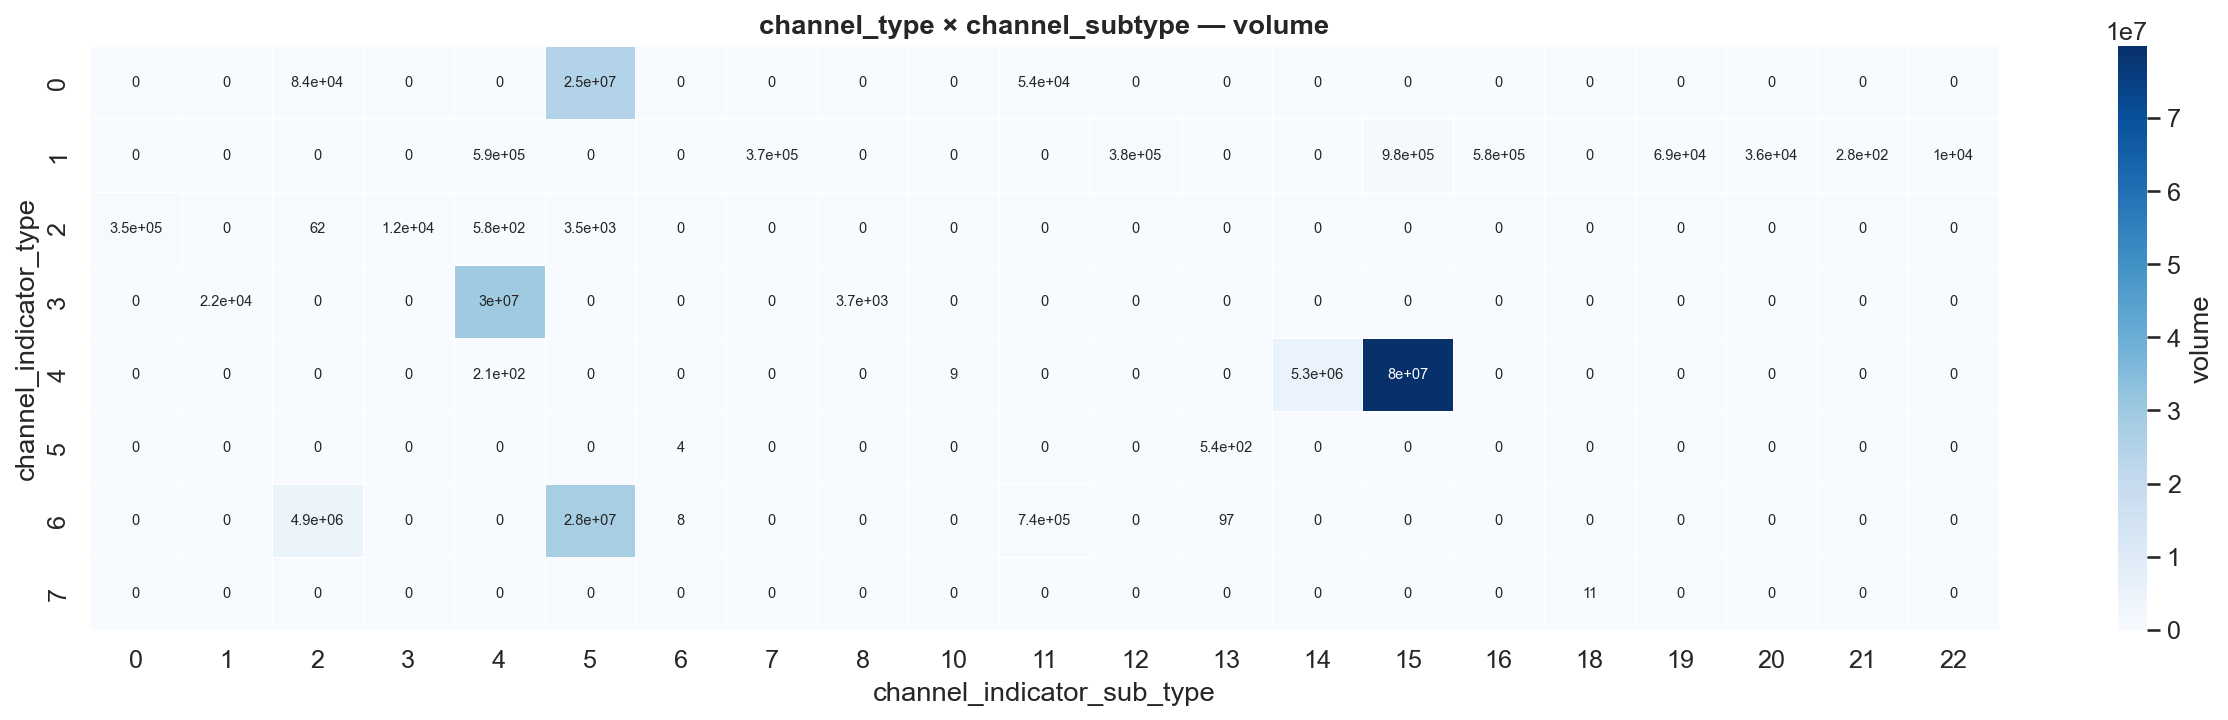

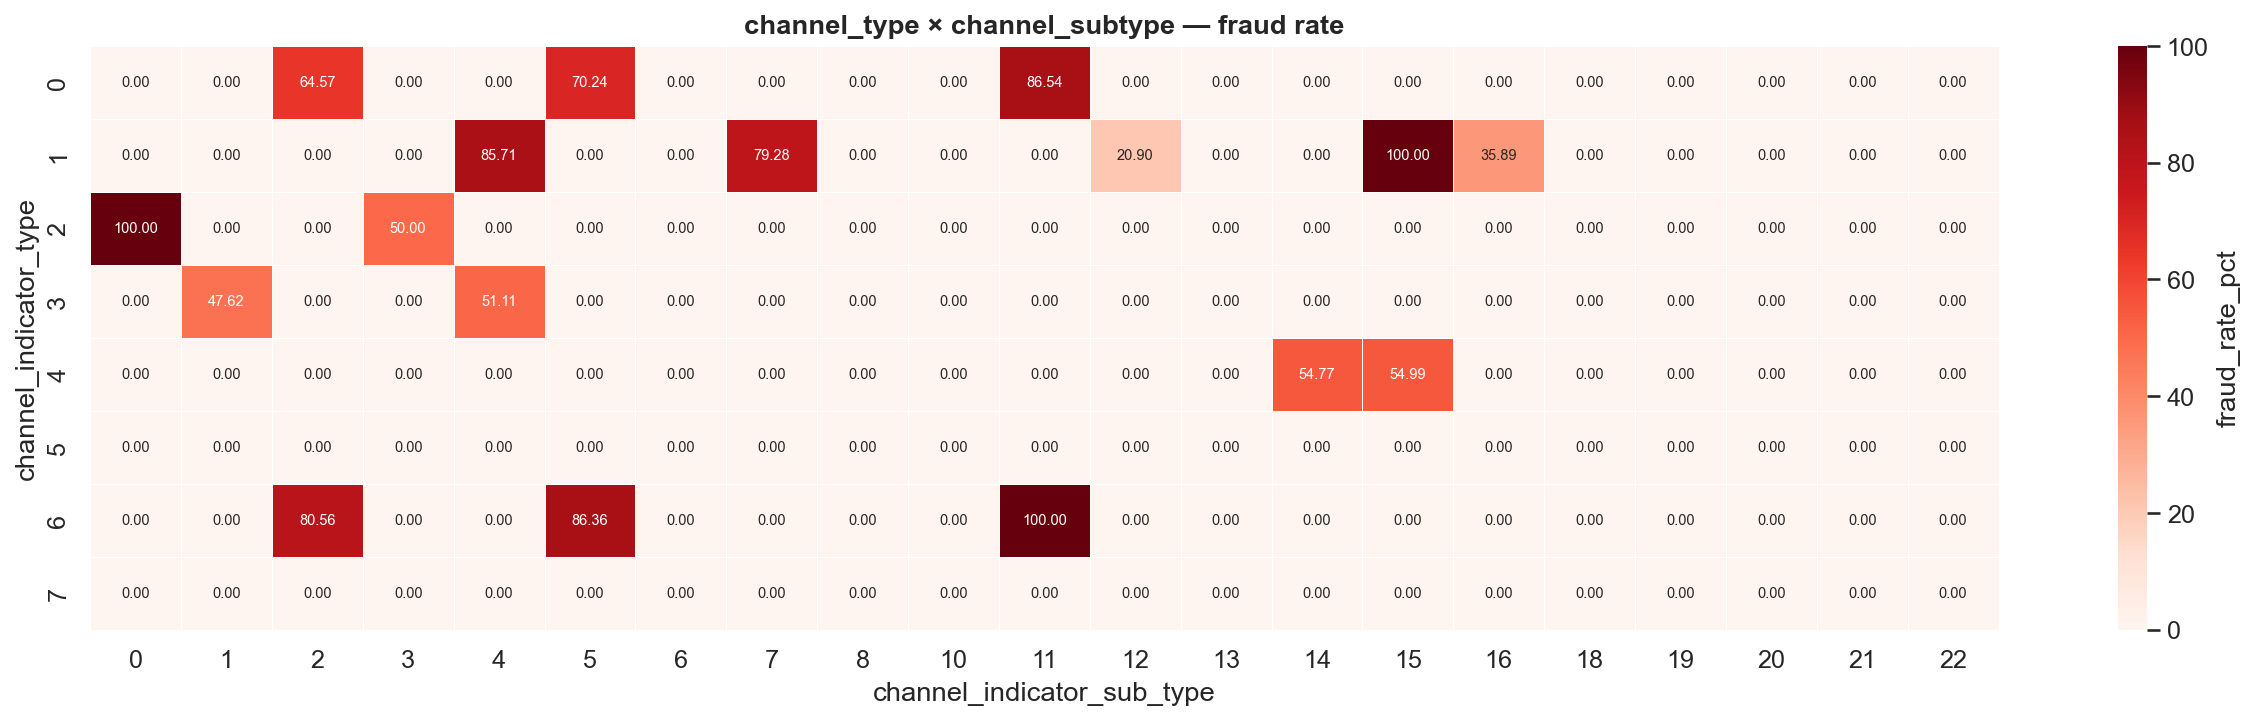


Top channel pairs by fraud rate (min 100 labeled rows):



,channel_indicator_type,channel_indicator_sub_type,volume,fraud_count,labeled_count,fraud_rate_pct
0,0,11,"54,318",135,156,86.538%
1,1,7,"368,656",463,584,79.281%
2,0,5,"24,849,150","17,690",25186,70.237%
3,0,2,"84,281",82,127,64.567%
4,4,15,"79,820,557","23,392",42541,54.987%
5,4,14,"5,292,346","1,526",2786,54.774%
6,3,4,"29,894,661","7,710",15084,51.114%
7,1,16,"576,107",290,808,35.891%


In [8]:

print("Computing channel_indicator_type × channel_indicator_sub_type …")

ch_pair = (
    lf_all
    .group_by(["channel_indicator_type", "channel_indicator_sub_type"])
    .agg(pl.len().alias("volume"))
    .collect()
)

ch_fraud = (
    lf_labeled
    .group_by(["channel_indicator_type", "channel_indicator_sub_type"])
    .agg(
        pl.col("target").sum().alias("fraud_count"),
        pl.len().alias("labeled_count"),
    )
    .collect()
)

ch_pair = (
    ch_pair
    .join(ch_fraud, on=["channel_indicator_type", "channel_indicator_sub_type"], how="left")
    .with_columns(
        (pl.col("fraud_count") / pl.col("labeled_count") * 100).alias("fraud_rate_pct")
    )
    .sort("volume", descending=True)
)

# Volume heatmap
def _pivot_heatmap(df, value_col, title, fmt=".1f", cmap="Blues"):
    pdf = df.to_pandas()
    pivot = pdf.pivot_table(
        index="channel_indicator_type",
        columns="channel_indicator_sub_type",
        values=value_col,
        aggfunc="sum",
        fill_value=0,
    )
    fig, ax = plt.subplots(figsize=(max(8, pivot.shape[1] * 0.8),
                                    max(5, pivot.shape[0] * 0.6)), dpi=150)
    sns.heatmap(pivot, ax=ax, cmap=cmap, fmt=fmt,
                annot=pivot.shape[0] * pivot.shape[1] <= 200,
                annot_kws={"fontsize": 7},
                linewidths=0.3, linecolor="white",
                cbar_kws={"label": value_col})
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

_pivot_heatmap(ch_pair, "volume",         "channel_type × channel_subtype — volume",    fmt=".2g", cmap="Blues")
_pivot_heatmap(ch_pair, "fraud_rate_pct", "channel_type × channel_subtype — fraud rate", fmt=".2f", cmap="Reds")

print("\nTop channel pairs by fraud rate (min 100 labeled rows):\n")
display(
    ch_pair
    .filter(pl.col("labeled_count") >= 100)
    .sort("fraud_rate_pct", descending=True)
    .head(30)
    .to_pandas()
    .style
    .format({"volume": "{:,.0f}", "fraud_count": "{:,.0f}", "fraud_rate_pct": "{:.3f}%"})
    .background_gradient(subset=["fraud_rate_pct"], cmap="Reds")
)
ch_pair.write_csv(OUT_DIR / "channel_type_subtype_pairs.csv")

In [11]:
# Based on the stats above, compute a compact summary of the highest-fraud
# (event_type_nm, event_desc) pairs within each tx_type_group.
# These are natural split points for further model specialisation.

print("High-fraud sub-groups within each tx_type_group:\n")

for gid, gname in GROUP_LABELS.items():
    sub = (
        pair_stats
        .filter(
            (pl.col("tx_type_group") == gid) &
            (pl.col("labeled_count") >= 50)
        )
        .sort("fraud_rate_pct", descending=True)
        .head(20)
    )
    total_vol = pair_stats.filter(pl.col("tx_type_group") == gid)["volume"].sum()
    print(f"{'='*65}")
    print(f"  Group {gid} — {gname.upper()}")
    print(f"  Total volume: {total_vol:,.0f}")
    print(f"{'='*65}")
    res = sub.select(["event_type_nm", "event_desc", "volume", "fraud_count", "labeled_count", "fraud_rate_pct"])
    # Save
    res.write_csv(OUT_DIR / f"high_fraud_pairs_group_{gid}.csv")
    display(
        sub.select(["event_type_nm", "event_desc", "volume", "fraud_count", "labeled_count", "fraud_rate_pct"])
        .to_pandas()
        .style
        .format({"volume": "{:,.0f}", "fraud_count": "{:,.0f}", "fraud_rate_pct": "{:.3f}%"})
        .background_gradient(subset=["fraud_rate_pct"], cmap="Reds")
        .set_caption(f"Top fraud-prone (event_type_nm, event_desc) pairs — {gname}")
    )
    print()

High-fraud sub-groups within each tx_type_group:

  Group 0 — NONPAYMENT
  Total volume: 77,648,013


,event_type_nm,event_desc,volume,fraud_count,labeled_count,fraud_rate_pct
0,12,12,"9,639",68,82,82.927%
1,10,80,"15,458",72,100,72.000%
2,6,38,"166,981",180,253,71.146%
3,0,47,"103,202",49,72,68.056%
4,11,23,"23,666",66,102,64.706%
5,10,106,"60,551",83,131,63.359%
6,2,20,"596,106",38,61,62.295%
7,0,118,"30,238",43,71,60.563%
8,12,50,"13,427",32,53,60.377%
9,7,56,"69,787,085","17,688",30432,58.123%



  Group 1 — CARD
  Total volume: 53,775,276


,event_type_nm,event_desc,volume,fraud_count,labeled_count,fraud_rate_pct
0,14,73,"413,766","1,926",2061,93.450%
1,14,75,"49,473,548","12,562",17194,73.060%
2,3,120,"1,861,304","1,669",2799,59.628%
3,9,28,"414,846",136,243,55.967%
4,14,44,"81,069",35,64,54.688%
5,2,88,"3,098","1,333",2583,51.607%
6,9,26,"623,792",78,276,28.261%



  Group 2 — P2P
  Total volume: 45,194,508


,event_type_nm,event_desc,volume,fraud_count,labeled_count,fraud_rate_pct
0,14,73,3,"1,926",2061,93.450%
1,14,29,"335,889",381,459,83.007%
2,14,31,"360,375","1,348",1641,82.145%
3,8,119,"186,270",140,176,79.545%
4,14,113,"55,290",463,610,75.902%
5,15,109,"101,767",217,296,73.311%
6,14,75,"1,641,519","12,562",17194,73.060%
7,9,37,"1,950,031","1,047",1546,67.723%
8,9,105,"94,118",52,77,67.532%
9,8,18,"12,301",37,56,66.071%


Fraud rate distribution across categorical values …


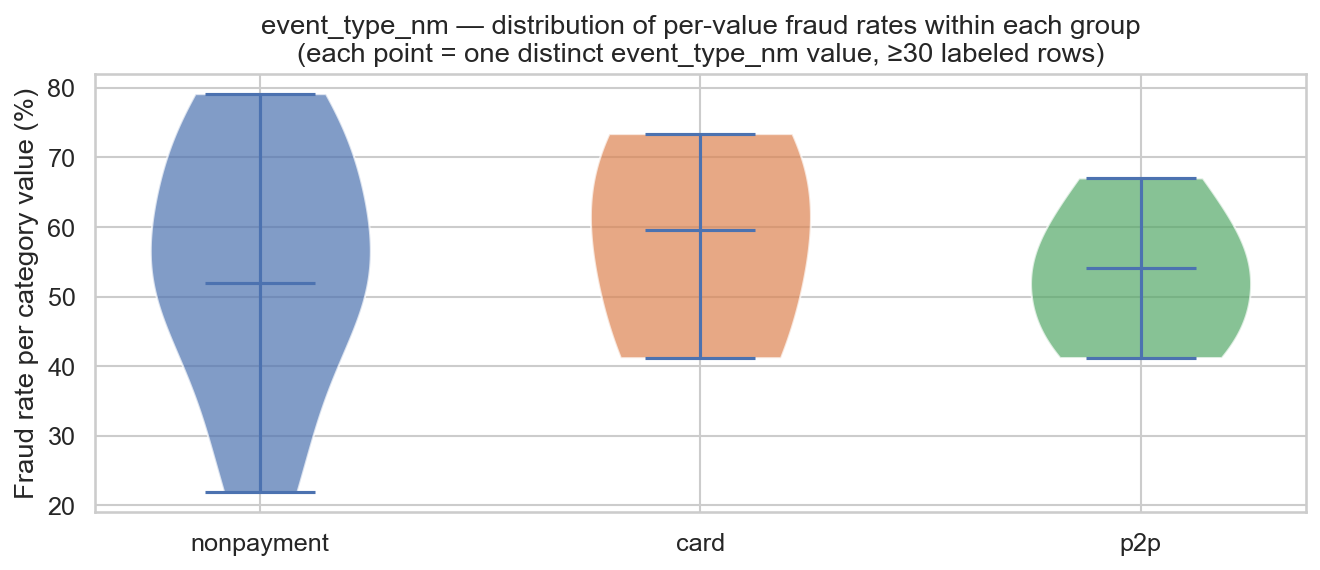

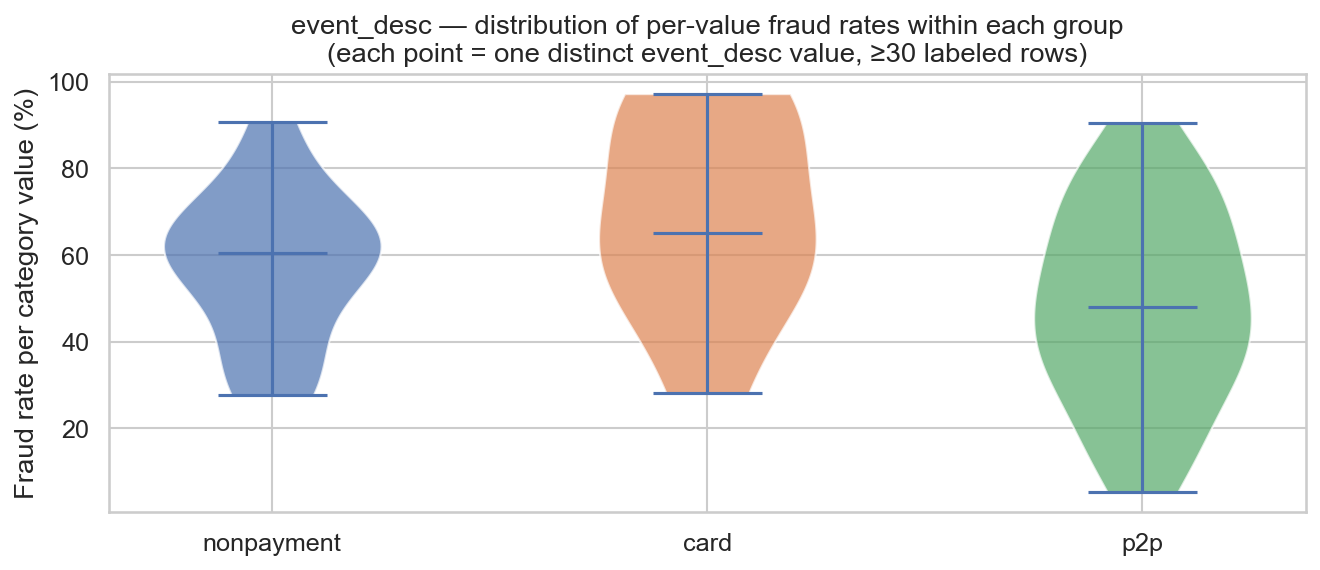

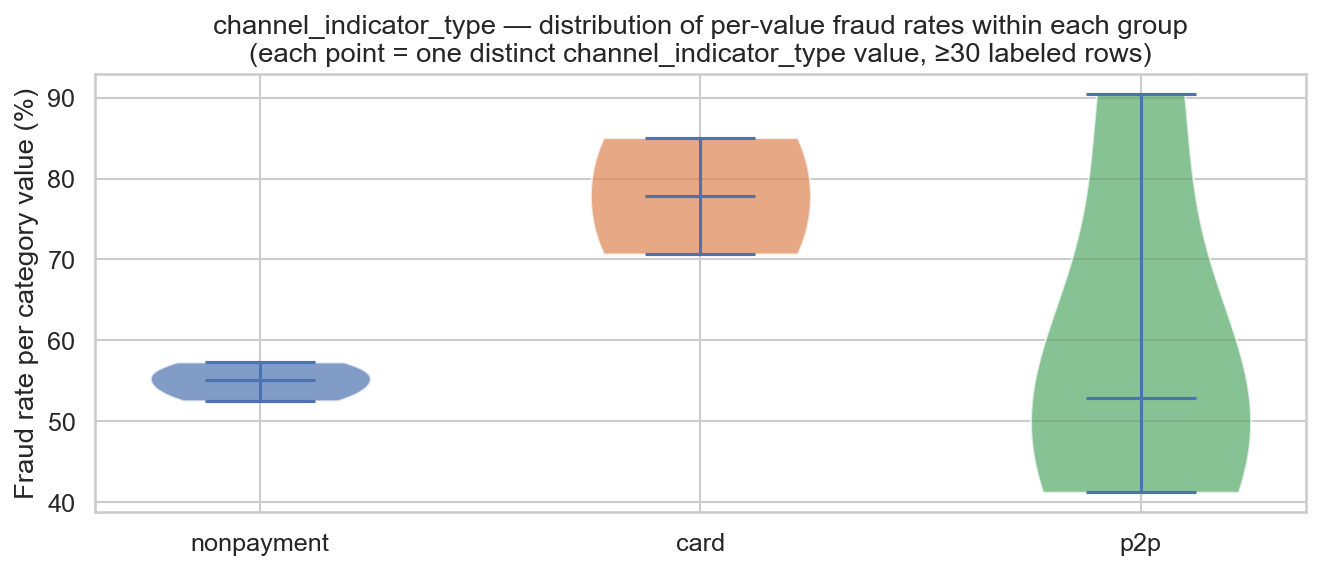

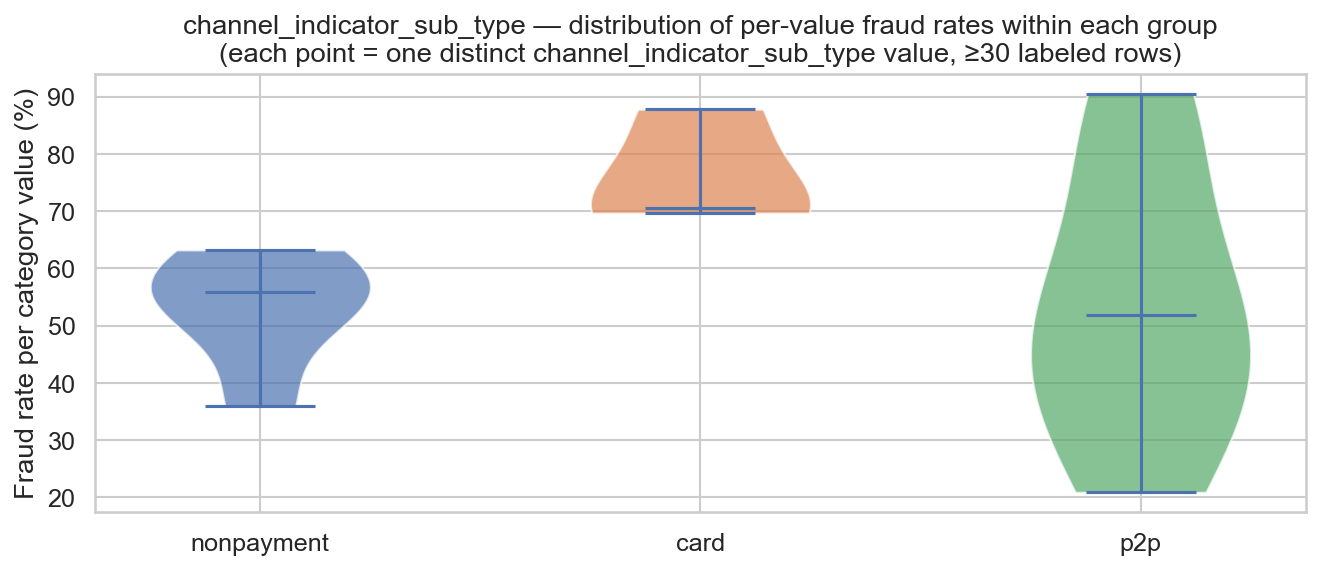

Analysis complete.


In [12]:
# Violin / box plots of fraud_rate_pct distribution across values within each group.
# Quickly shows whether fraud is concentrated in a few values or spread evenly.

print("Fraud rate distribution across categorical values …")

for col_name in CATS:
    wg = within_group_stats(col_name)
    pdf = wg.filter(pl.col("labeled_count") >= 30).to_pandas()

    if pdf.empty:
        continue

    fig, ax = plt.subplots(figsize=(9, 4), dpi=150)
    data_by_group = [
        pdf.loc[pdf["tx_type_group"] == gid, "fraud_rate_pct"].dropna().values
        for gid in [0, 1, 2]
    ]
    parts = ax.violinplot(
        [d for d in data_by_group if len(d) > 1],
        positions=[gid for gid, d in enumerate(data_by_group) if len(d) > 1],
        showmedians=True, showextrema=True,
    )
    for pc, gid in zip(parts["bodies"],
                       [gid for gid, d in enumerate(data_by_group) if len(d) > 1]):
        pc.set_facecolor(GROUP_COLORS[gid])
        pc.set_alpha(0.7)

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([GROUP_LABELS[g] for g in [0, 1, 2]])
    ax.set_ylabel("Fraud rate per category value (%)")
    ax.set_title(
        f"{col_name} — distribution of per-value fraud rates within each group\n"
        f"(each point = one distinct {col_name} value, ≥30 labeled rows)"
    )
    plt.tight_layout()
    plt.show()

print("Analysis complete.")